In [12]:
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# Font size settings for figures
mpl.rcParams.update({
    "font.size": 14,              # base font size
    "axes.titlesize": 16,         # title font
    "axes.labelsize": 14,         # x/y label font
    "xtick.labelsize": 12,        # x-tick labels
    "ytick.labelsize": 12,        # y-tick labels
    "legend.fontsize": 12,        # legend text
    "lines.linewidth": 2,         # line thickness
    "axes.linewidth": 1.2,        # axis border thickness
})

# Function to make annotating data on figures easier
def annotate_final_values(ax, x, y_values, labels, min_sep_frac=0.1):
    """
    Adds annotations at the final time point of each y-series with spacing done in axis-fraction units.

    Parameters:
        ax: matplotlib Axes object
        x: time points (1D array)
        y_values: list of y-arrays
        labels: list of label strings
        min_sep_frac: minimum spacing between annotations in axis fraction (0.03 = 3% of y-axis height)
    """
    final_x = x[-1]
    final_ys = [y[-1] for y in y_values]
    y_min, y_max = ax.get_ylim()

    # Convert y-values to axis-fraction space
    y_fracs = [(y - y_min) / (y_max - y_min) for y in final_ys]

    # Sort and apply minimum spacing in axis-fraction space
    sorted_indices = np.argsort(y_fracs)
    new_frac_positions = {}
    last_frac = None
    for idx in sorted_indices:
        frac = y_fracs[idx]
        if last_frac is None:
            new_frac_positions[idx] = frac
        else:
            new_frac_positions[idx] = max(frac, last_frac + min_sep_frac)
        last_frac = new_frac_positions[idx]

    # Clamp to [0,1] and convert back to data coordinates
    for idx in range(len(y_values)):
        orig_y = final_ys[idx]
        frac_y = min(new_frac_positions[idx], 0.98)  # avoid going out of bounds
        adjusted_y = y_min + frac_y * (y_max - y_min)

        ax.annotate(f"{labels[idx]}\n{orig_y:.0f}",
                    xy=(final_x, orig_y),
                    xytext=(final_x + 1, adjusted_y),
                    textcoords='data',
                    fontsize=8,
                    va='center',
                    ha='left',
                    arrowprops=dict(arrowstyle='->', lw=0.5),
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", lw=0.5))

# Saturating Volume-Scaled Neuroblast Growth and Division Threshold Sizer Model

## Model Species
- **$N_{\text{NB}}, V_{\text{NB}}$** — Neuroblast count & total NB volume
- **$N_{\text{GMC}}, V_{\text{GMC}}$** — GMC count & total GMC volume
- **$N_{\text{ImNeuron}}, V_{\text{ImNeuron}}$** — Immature neuron count & volume
- **$N_{\text{MatNeuron}}, V_{\text{MatNeuron}}$** — Mature neuron count & volume

## Model Parameters
- $g_{\text{NB,base}}$ — Base NB growth rate
- $g_{\text{GMC}}$ — GMC growth rate
- $k_{\text{Neuron}}$ — Neuron maturation rate
- $\text{sym\_frac}$ — Fraction of symmetric NB divisions
- $V_{\text{ref}}$ — Reference NB volume for scaling (equal to WT NB division threshold)
- $V_{\text{thresh,base}}$ — Base NB division threshold (currently setting equal to $V_{\text{ref}}$)
- $V_{\text{thresh,GMC}}$ — GMC division threshold
- $V_{\text{floor,NB}}$ — Minimum NB volume required for division
- $k_{\text{max,NB}}$ — Maximum NB division rate
- $k_{\text{max,GMC}}$ — Maximum GMC division rate
- $n$ — Hill coefficient controlling steepness of the division rate response to volume
- $\alpha_{\text{growth}}$ — Scaling exponent for NB growth rate reduction at small volumes
- $\alpha_{\text{thresh}}$ — Scaling exponent for NB division threshold reduction at small volumes

## Model Terms

### Average Cell Volumes
The average volume for each species is the total volume of the species divided by the number of cells of that species:
$$
\bar{V}_{\text{NB}} = \frac{V_{\text{NB}}}{N_{\text{NB}}}, \quad
\bar{V}_{\text{GMC}} = \frac{V_{\text{GMC}}}{N_{\text{GMC}}}, \quad
\bar{V}_{\text{ImNeuron}} = \frac{V_{\text{ImNeuron}}}{N_{\text{ImNeuron}}}
$$

### Scaling Mechanisms for Neuroblast Growth Rate and Division Threshold
This model uses two power‐law scaling rules to adjust the neuroblast (NB) growth rate and NB division threshold based on the current average NB volume $\bar{V}{\text{NB}}$. Both are expressed relative to a reference volume $V{\text{ref}}$, set equal to the WT NB division threshold. This threshold is roughly the largest NB volume expected during simulations, making the provided base growth rate $g_{\text{NB,base}}$ and base threshold $V_{\text{ref}}$ roughly represent maximum possible values in the model. Any decrease in $\bar{V}{\text{NB}}$ below $V{\text{ref}}$ proportionally reduces growth rate and threshold according to the scaling exponents.

**Growth Rate Scaling**

When $\bar{V}{\text{NB}}$ is smaller than $V{\text{ref}}$, the NB growth rate is reduced. The exponent $\alpha_{\text{growth}}$ controls the sensitivity of this slowdown: higher values mean stronger reduction for small cells.

$$
g_{\text{NB,eff}} = g_{\text{NB,base}} \cdot \left( \frac{\bar{V}{\text{NB}}}{V{\text{ref}}} \right)^{\alpha_{\text{growth}}}
$$
- $g_{\text{NB,base}}$ – Maximum NB growth rate (when $\bar{V}{\text{NB}} = V{\text{ref}}$).
- $\alpha_{\text{growth}}$ – Scaling strength: larger values produce greater slowdown at smaller sizes.

**Division Threshold Scaling**

The NB division threshold volume is reduced in proportion to $\bar{V}{\text{NB}}$ when cells are smaller than $V{\text{ref}}$. The exponent $\alpha_{\text{thresh}}$ controls how strongly the threshold is reduced.

$$
V_{\text{thresh,eff}} = V_{\text{ref}} \cdot \left( \frac{\bar{V}{\text{NB}}}{V{\text{ref}}} \right)^{\alpha_{\text{thresh}}}
$$
- $V_{\text{ref}}$ – WT NB division threshold volume (maximum threshold in the model).
- $\alpha_{\text{thresh}}$ – Scaling strength: larger values reduce the threshold more sharply for smaller cells.

### NB Division Rate
The neuroblast division rate depends on whether the average neuroblast volume $\bar{V}_{\text{NB}}$ has reached the effective division threshold $V_{\text{thresh,eff}}$. This relationship is modeled with a **saturating sizer function** rather than a Hill function. Division rate increases as a power law with $\bar{V}_{\text{NB}}$ below the threshold, then saturates at the maximum rate once the threshold is reached. Neuroblasts must also exceed a minimum volume $V_{\text{floor,NB}}$ before they can divide.

$$
k_{\text{NB}} =
\begin{cases}
k_{\text{max,NB}} \cdot \min\!\left(1,\;\left(\tfrac{\bar{V}_{\text{NB}}}{V_{\text{thresh,eff}}}\right)^{n}\right), & \text{if } \bar{V}_{\text{NB}} \ge V_{\text{floor,NB}} \\
0, & \text{otherwise}
\end{cases}
$$

- $k_{\text{max,NB}}$ – Maximum possible NB division rate.
- $n$ – Exponent controlling how sharply the rate rises as the threshold is approached.
- $V_{\text{thresh,eff}}$ – Effective division threshold volume (scaled as described in Scaling Mechanisms).
- $V_{\text{floor,NB}}$ – Minimum cell volume required for division to be possible.

This form guarantees that division rate grows smoothly with cell size, reaches the maximal division rate when the average NB volume equals the division threshold, and ensures the division rate cannot exceed $k_{\text{max,NB}}$ once the threshold is reached.

### GMC Division Rate
Similar to the NB division rate, the GMC division rate depends on whether the average GMC volume $\bar{V}{\text{GMC}}$ has reached the GMC division threshold $V_{\text{thresh,GMC}}$. The same saturating sizer rule is applied.

If there are no GMCs present ($N_{\text{GMC}} = 0$), the division rate is set to zero.

$$
k_{\text{GMC}} =
\begin{cases}
k_{\text{max,GMC}} \cdot \min\!\left(1,\;\left(\tfrac{\bar{V}_{\text{GMC}}}{V_{\text{thresh,GMC}}}\right)^{n}\right), & \text{if } N_{\text{GMC}} > 0 \\
0, & \text{otherwise}
\end{cases}
$$

- $k_{\text{max,GMC}}$ – Maximum possible GMC division rate.
- $V_{\text{thresh,GMC}}$ – GMC division threshold volume.
- $n$ – Exponent controlling the sharpness of the rise in division rate as the threshold is approached.

Thus, both neuroblasts and GMCs follow a **saturating sizer mechanism**: division readiness is determined by how close average volume is to a threshold, with the rate capped once the threshold is reached.

### Partitioning of Neuroblast Divisions
This model partitions all neuroblast (NB) divisions into two categories: symmetric and asymmetric. The parameter $\text{sym\_frac}$ specifies the fraction of NB divisions that are symmetric.
- Symmetric divisions produce two daughter NBs.
- Asymmetric divisions produce one NB and one GMC.

The number of each type of division per time step is proportional to the NB division rate $k_{\text{NB}}$ and the current number of neuroblasts $N_{\text{NB}}$:

$$
\text{sym\_divs} = \text{sym\_frac} \cdot k_{\text{NB}} \cdot N_{\text{NB}}, \quad
\text{asym\_divs} = (1 - \text{sym\_frac}) \cdot k_{\text{NB}} \cdot N_{\text{NB}}
$$
- $\text{sym\_frac}$ – Fraction of divisions that are symmetric.
- $k_{\text{NB}}$ – Effective NB division rate (from Hill equation or other regulation).
- $N_{\text{NB}}$ – Current number of neuroblasts in the population.

## Python Code

In [13]:
def neuroblast_model_vol_scaled_growth_and_threshold_satpow(t, y, params):
    """
    NB growth and NB division threshold scale with current NB size.
    Division rates use a saturating power law:
        k_eff = k_max * min(1, (Vbar / V_thresh)^n)

    NB uses an NB volume floor (V_floor_NB); GMC does not.
    """
    (N_NB, V_NB,
     N_GMC, V_GMC,
     N_ImNeuron, V_ImNeuron,
     N_MatNeuron, V_MatNeuron) = y

    (g_NB_base, g_GMC,
     k_Neuron,
     sym_frac,
     V_thresh_base,
     V_thresh_GMC,
     k_max_NB, k_max_GMC,
     n,
     V_floor_NB,
     V_ref,
     alpha_growth, alpha_thresh) = params

    # Averages (guard zero)
    Vavg_NB       = V_NB / N_NB if N_NB > 0 else 0.0
    Vavg_GMC      = V_GMC / N_GMC if N_GMC > 0 else 0.0
    Vavg_ImNeuron = V_ImNeuron / N_ImNeuron if N_ImNeuron > 0 else 0.0

    # Instantaneous NB scaling
    ratio        = (Vavg_NB / V_ref) if V_ref > 0 else 1.0
    g_NB_eff     = g_NB_base * (ratio ** alpha_growth)
    V_thresh_eff = V_thresh_base * (ratio ** alpha_thresh)

    # Helper: k = kmax * min(1, (Vbar/Vthresh)^n), with guards
    def satpow_rate(Vbar, Vthresh, kmax, n):
        if Vbar <= 0 or Vthresh <= 0:
            return 0.0
        r = (Vbar / Vthresh) ** n
        return kmax * (1.0 if r >= 1.0 else r)

    # NB division rate (apply floor)
    if N_NB > 0 and Vavg_NB >= V_floor_NB and V_thresh_eff > 0:
        k_NB = satpow_rate(Vavg_NB, V_thresh_eff, k_max_NB, n)
    else:
        k_NB = 0.0

    # GMC division rate (fixed threshold)
    if N_GMC > 0 and V_thresh_GMC > 0:
        k_GMC = satpow_rate(Vavg_GMC, V_thresh_GMC, k_max_GMC, n)
    else:
        k_GMC = 0.0

    # Division fluxes
    sym_divs  = sym_frac * k_NB * N_NB
    asym_divs = (1.0 - sym_frac) * k_NB * N_NB

    # ODEs
    dN_NB = sym_divs
    dV_NB = g_NB_eff * N_NB - 0.2 * asym_divs * Vavg_NB

    dN_GMC = asym_divs - k_GMC * N_GMC
    dV_GMC = g_GMC * N_GMC + 0.2 * asym_divs * Vavg_NB - k_GMC * N_GMC * Vavg_GMC

    dN_ImNeuron = 2.0 * k_GMC * N_GMC - k_Neuron * N_ImNeuron
    dV_ImNeuron = k_GMC * N_GMC * Vavg_GMC - k_Neuron * N_ImNeuron * Vavg_ImNeuron

    dN_MatNeuron = k_Neuron * N_ImNeuron
    dV_MatNeuron = k_Neuron * N_ImNeuron * Vavg_ImNeuron

    return [
        dN_NB, dV_NB,
        dN_GMC, dV_GMC,
        dN_ImNeuron, dV_ImNeuron,
        dN_MatNeuron, dV_MatNeuron
    ]

WT Simulation

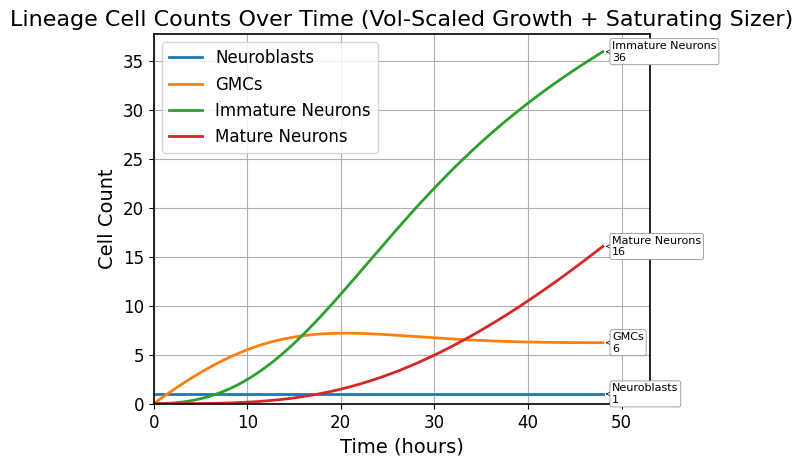

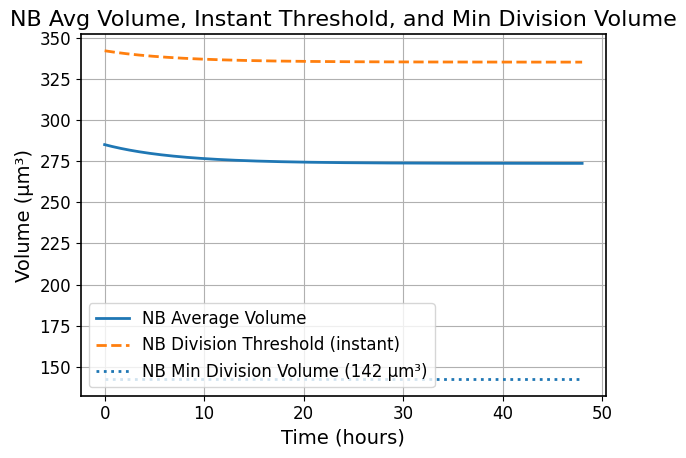

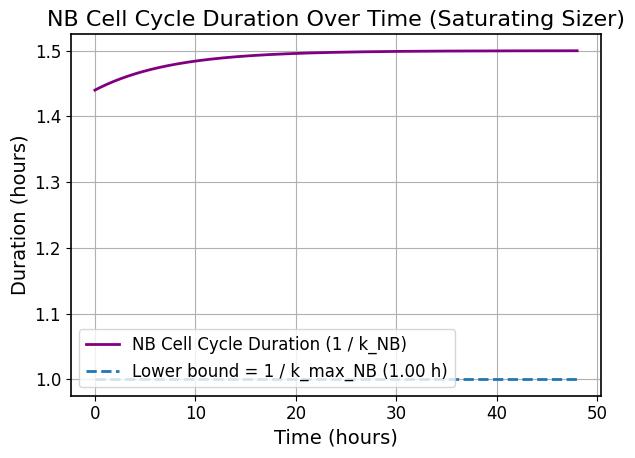

In [14]:
# --- WT params (volume-scaled growth + saturating sizer division) ---
nb_vol = 285                                # Initial neuroblast volume (µm³)

V_thresh_base = 1.2 * nb_vol                # Base NB threshold at V_ref
g_NB_base = nb_vol * 0.2 / 1.5              # NB base growth rate (volume/hr)
g_GMC     = (nb_vol * 1.2 * 0.2) / 9        # GMC growth rate (volume/hr)

V_thresh_GMC = (nb_vol * 1.2 * 0.2) * 2     # GMC division threshold volume (µm³)
k_max_NB  = 1.0                             # Max NB division rate (divisions/hr)
k_max_GMC = 1.0 / 8.0                       # Max GMC division rate (divisions/hr)
n         = 2                               # Exponent in the saturating sizer

sym_frac  = 0.0                             # Fraction of NB divisions that are symmetric
k_Neuron  = 1.0 / 48.0                      # Immature neuron maturation rate (1/hr)
V_floor_NB    = nb_vol / 2.0                # Min avg NB volume before division allowed

# NB growth rate and division threshold scaling parameters
V_ref         = nb_vol                      # Reference volume for NB growth/threshold scaling
alpha_growth  = 1.0                         # Growth sensitivity to NB volume
alpha_thresh  = 0.5                         # Threshold sensitivity to NB volume (small)

# Parameter order for the saturating model:
# (g_NB_base, g_GMC, k_Neuron, sym_frac,
#  V_thresh_base, V_thresh_GMC,
#  k_max_NB, k_max_GMC, n,
#  V_floor_NB, V_ref, alpha_growth, alpha_thresh)
params_vol_scaled_sat = [
    g_NB_base, g_GMC,
    k_Neuron,
    sym_frac,
    V_thresh_base, V_thresh_GMC,
    k_max_NB, k_max_GMC,
    n,
    V_floor_NB, V_ref,
    alpha_growth, alpha_thresh
]

# Initial conditions
# [N_NB, V_NB, N_GMC, V_GMC, N_ImNeuron, V_ImNeuron, N_MatNeuron, V_MatNeuron]
y0 = [1, nb_vol, 0, 0, 0, 0, 0, 0]

t_span = [0, 48]
t_eval = np.linspace(*t_span, 500)

# --- Solve ---
sol_vol_scaled = solve_ivp(
    neuroblast_model_vol_scaled_growth_and_threshold_satpow,
    t_span, y0, t_eval=t_eval, args=(params_vol_scaled_sat,),
    rtol=1e-6, atol=1e-9
)

# ========== Plot 1: Cell counts ==========
fig, ax = plt.subplots()
labels  = ["Neuroblasts", "GMCs", "Immature Neurons", "Mature Neurons"]
indices = [0, 2, 4, 6]
y_data  = [sol_vol_scaled.y[i] for i in indices]

for y, label in zip(y_data, labels):
    ax.plot(sol_vol_scaled.t, y, label=label)

ax.set_xlim(0, sol_vol_scaled.t[-1] + 5)
ax.set_ylim(bottom=0)
try:
    annotate_final_values(ax, sol_vol_scaled.t, y_data, labels)
except NameError:
    pass
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Cell Count")
ax.set_title("Lineage Cell Counts Over Time (Vol-Scaled Growth + Saturating Sizer)")
ax.grid()
ax.legend()
plt.show()

# ========== Plot 2: NB avg volume vs threshold (+ floor) ==========
Vavg_NB = np.divide(sol_vol_scaled.y[1], sol_vol_scaled.y[0],
                    out=np.zeros_like(sol_vol_scaled.y[1]),
                    where=sol_vol_scaled.y[0] > 0)

# Instantaneous threshold over time (scaled to NB avg volume):
Vthresh_NB_t = V_thresh_base * (np.divide(Vavg_NB, V_ref,
                                          out=np.ones_like(Vavg_NB),
                                          where=V_ref > 0) ** alpha_thresh)

fig, ax = plt.subplots()
ax.plot(sol_vol_scaled.t, Vavg_NB, label="NB Average Volume", linewidth=2)
ax.plot(sol_vol_scaled.t, Vthresh_NB_t, '--', label="NB Division Threshold (instant)")
ax.hlines(V_floor_NB, sol_vol_scaled.t[0], sol_vol_scaled.t[-1],
          linestyles=":", label=f"NB Min Division Volume ({V_floor_NB:.0f} µm³)")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Volume (µm³)")
ax.set_title("NB Avg Volume, Instant Threshold, and Min Division Volume")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

# ========== Plot 3: NB cell-cycle duration (1 / k_NB) ==========
# Recompute Vavg and ratio
Vavg_NB = np.divide(sol_vol_scaled.y[1], sol_vol_scaled.y[0],
                    out=np.zeros_like(sol_vol_scaled.y[1]),
                    where=sol_vol_scaled.y[0] > 0)
ratio = np.divide(Vavg_NB, V_ref, out=np.ones_like(Vavg_NB), where=V_ref > 0)

# Instant effective threshold series for NBs
V_thresh_eff_series = V_thresh_base * (ratio ** alpha_thresh)

# Instantaneous NB division rate using saturating sizer:
with np.errstate(divide='ignore', invalid='ignore'):
    # core saturating term: min(1, (Vavg_NB / V_thresh_eff)^n)
    core = np.where(V_thresh_eff_series > 0,
                    (Vavg_NB / V_thresh_eff_series) ** n,
                    0.0)
    core = np.minimum(core, 1.0)
    k_NB_series = np.where(
        Vavg_NB >= V_floor_NB,
        k_max_NB * core,
        0.0
    )

# Cell-cycle duration = 1 / k_NB (NaN when k_NB = 0)
ccd_hazard = np.where(k_NB_series > 0, 1.0 / k_NB_series, np.nan)

fig, ax = plt.subplots()
ax.plot(sol_vol_scaled.t, ccd_hazard, color="purple", label="NB Cell Cycle Duration (1 / k_NB)")
ax.hlines(1.0 / k_max_NB, sol_vol_scaled.t[0], sol_vol_scaled.t[-1],
          linestyles="--", label=f"Lower bound = 1 / k_max_NB ({1.0/k_max_NB:.2f} h)")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Duration (hours)")
ax.set_title("NB Cell Cycle Duration Over Time (Saturating Sizer)")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

mudmut simulation

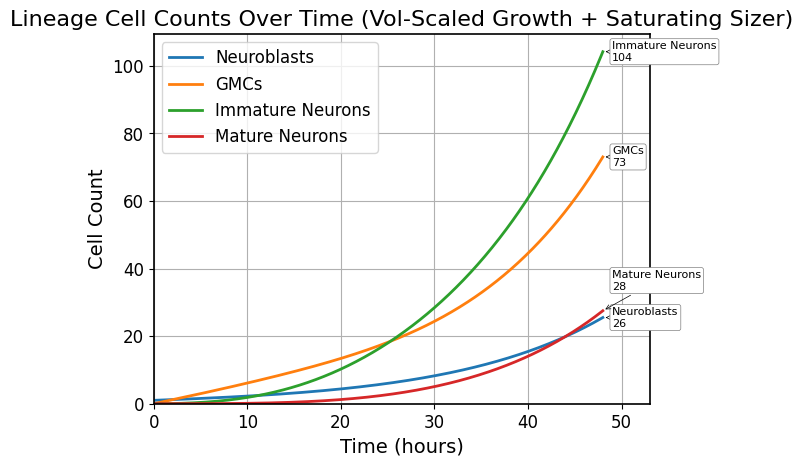

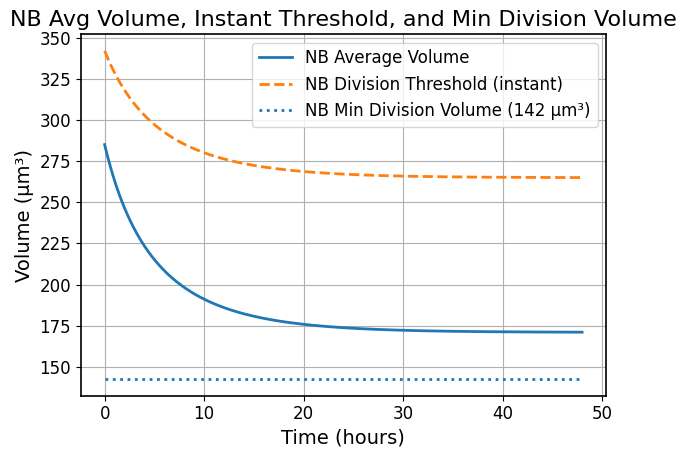

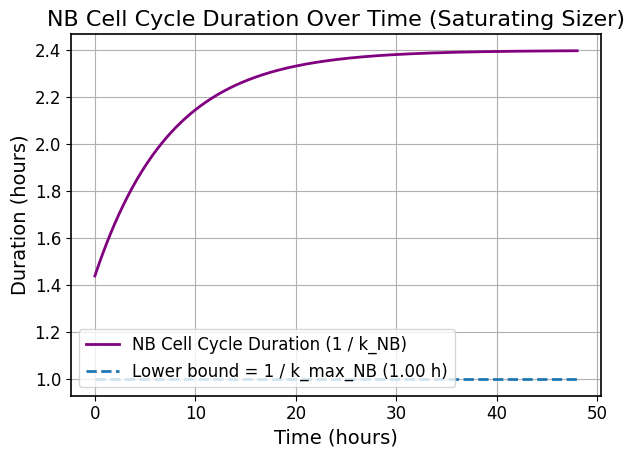

In [15]:
# --- mudmut params (volume-scaled growth + saturating sizer division) ---
nb_vol = 285                                # Initial neuroblast volume (µm³)

V_thresh_base = 1.2 * nb_vol                # Base NB threshold at V_ref
g_NB_base = nb_vol * 0.2 / 1.5              # NB base growth rate (volume/hr)
g_GMC     = (nb_vol * 1.2 * 0.2) / 9        # GMC growth rate (volume/hr)

V_thresh_GMC = (nb_vol * 1.2 * 0.2) * 2     # GMC division threshold volume (µm³)
k_max_NB  = 1.0                             # Max NB division rate (divisions/hr)
k_max_GMC = 1.0 / 8.0                       # Max GMC division rate (divisions/hr)
n         = 2                               # Exponent in the saturating sizer

sym_frac  = 0.15                            # Fraction of NB divisions that are symmetric
k_Neuron  = 1.0 / 48.0                      # Immature neuron maturation rate (1/hr)
V_floor_NB    = nb_vol / 2.0                # Min avg NB volume before division allowed

# NB growth rate and division threshold scaling parameters
V_ref         = nb_vol                      # Reference volume for NB growth/threshold scaling
alpha_growth  = 1.0                         # Growth sensitivity to NB volume
alpha_thresh  = 0.5                         # Threshold sensitivity to NB volume (small)

# Parameter order for the saturating model:
# (g_NB_base, g_GMC, k_Neuron, sym_frac,
#  V_thresh_base, V_thresh_GMC,
#  k_max_NB, k_max_GMC, n,
#  V_floor_NB, V_ref, alpha_growth, alpha_thresh)
params_vol_scaled_sat = [
    g_NB_base, g_GMC,
    k_Neuron,
    sym_frac,
    V_thresh_base, V_thresh_GMC,
    k_max_NB, k_max_GMC,
    n,
    V_floor_NB, V_ref,
    alpha_growth, alpha_thresh
]

# Initial conditions
# [N_NB, V_NB, N_GMC, V_GMC, N_ImNeuron, V_ImNeuron, N_MatNeuron, V_MatNeuron]
y0 = [1, nb_vol, 0, 0, 0, 0, 0, 0]

t_span = [0, 48]
t_eval = np.linspace(*t_span, 500)

# --- Solve ---
sol_vol_scaled = solve_ivp(
    neuroblast_model_vol_scaled_growth_and_threshold_satpow,
    t_span, y0, t_eval=t_eval, args=(params_vol_scaled_sat,),
    rtol=1e-6, atol=1e-9
)

# ========== Plot 1: Cell counts ==========
fig, ax = plt.subplots()
labels  = ["Neuroblasts", "GMCs", "Immature Neurons", "Mature Neurons"]
indices = [0, 2, 4, 6]
y_data  = [sol_vol_scaled.y[i] for i in indices]

for y, label in zip(y_data, labels):
    ax.plot(sol_vol_scaled.t, y, label=label)

ax.set_xlim(0, sol_vol_scaled.t[-1] + 5)
ax.set_ylim(bottom=0)
try:
    annotate_final_values(ax, sol_vol_scaled.t, y_data, labels)
except NameError:
    pass
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Cell Count")
ax.set_title("Lineage Cell Counts Over Time (Vol-Scaled Growth + Saturating Sizer)")
ax.grid()
ax.legend()
plt.show()

# ========== Plot 2: NB avg volume vs threshold (+ floor) ==========
Vavg_NB = np.divide(sol_vol_scaled.y[1], sol_vol_scaled.y[0],
                    out=np.zeros_like(sol_vol_scaled.y[1]),
                    where=sol_vol_scaled.y[0] > 0)

# Instantaneous threshold over time (scaled to NB avg volume):
Vthresh_NB_t = V_thresh_base * (np.divide(Vavg_NB, V_ref,
                                          out=np.ones_like(Vavg_NB),
                                          where=V_ref > 0) ** alpha_thresh)

fig, ax = plt.subplots()
ax.plot(sol_vol_scaled.t, Vavg_NB, label="NB Average Volume", linewidth=2)
ax.plot(sol_vol_scaled.t, Vthresh_NB_t, '--', label="NB Division Threshold (instant)")
ax.hlines(V_floor_NB, sol_vol_scaled.t[0], sol_vol_scaled.t[-1],
          linestyles=":", label=f"NB Min Division Volume ({V_floor_NB:.0f} µm³)")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Volume (µm³)")
ax.set_title("NB Avg Volume, Instant Threshold, and Min Division Volume")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

# ========== Plot 3: NB cell-cycle duration (1 / k_NB) ==========
# Recompute Vavg and ratio
Vavg_NB = np.divide(sol_vol_scaled.y[1], sol_vol_scaled.y[0],
                    out=np.zeros_like(sol_vol_scaled.y[1]),
                    where=sol_vol_scaled.y[0] > 0)
ratio = np.divide(Vavg_NB, V_ref, out=np.ones_like(Vavg_NB), where=V_ref > 0)

# Instant effective threshold series for NBs
V_thresh_eff_series = V_thresh_base * (ratio ** alpha_thresh)

# Instantaneous NB division rate using saturating sizer:
with np.errstate(divide='ignore', invalid='ignore'):
    # core saturating term: min(1, (Vavg_NB / V_thresh_eff)^n)
    core = np.where(V_thresh_eff_series > 0,
                    (Vavg_NB / V_thresh_eff_series) ** n,
                    0.0)
    core = np.minimum(core, 1.0)
    k_NB_series = np.where(
        Vavg_NB >= V_floor_NB,
        k_max_NB * core,
        0.0
    )

# Cell-cycle duration = 1 / k_NB (NaN when k_NB = 0)
ccd_hazard = np.where(k_NB_series > 0, 1.0 / k_NB_series, np.nan)

fig, ax = plt.subplots()
ax.plot(sol_vol_scaled.t, ccd_hazard, color="purple", label="NB Cell Cycle Duration (1 / k_NB)")
ax.hlines(1.0 / k_max_NB, sol_vol_scaled.t[0], sol_vol_scaled.t[-1],
          linestyles="--", label=f"Lower bound = 1 / k_max_NB ({1.0/k_max_NB:.2f} h)")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Duration (hours)")
ax.set_title("NB Cell Cycle Duration Over Time (Saturating Sizer)")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

---

# Saturating Volume-Dependent Division Sizer Model

This model tracks both the number and total volume of each cell type in the developing neuroblast lineage. Division rates are **volume-dependent**, modeling a scenerio in which a cell will only divide if it has grown to a sufficient volume. There is no feedback in this model.

### Model Species
- **$N_{\text{NB}}$, $V_{\text{NB}}$** — Number and total volume of neuroblasts. Neuroblasts are stem-like cells that grow, and divide either symmetrically (producing two neuroblasts) or asymmetrically (producing one neuroblast and one GMC).
- **$N_{\text{GMC}}$, $V_{\text{GMC}}$** — Number and total volume of Ganglion Mother Cells (GMCs), which grow and divide symmetrically into two immature neurons.
- **$N_{\text{ImNeuron}}$, $V_{\text{ImNeuron}}$** — Number and total volume of immature neurons. These do not grow or divide, but they mature into mature neurons.
- **$N_{\text{MatNeuron}}$, $V_{\text{MatNeuron}}$** — Number and total volume of mature neurons, which do not grow, divide, or change state.

### Model Parameters
- **$g_{\text{NB}}$, $g_{\text{GMC}}$** — Growth rates (volume/hour) of neuroblasts and GMCs
- **$k_{\text{Neuron}}$** — Rate at which immature neurons mature into mature neurons (transitions/hour)
- **$V_{\text{thresh\_NB}}$, $V_{\text{thresh\_GMC}}$** — Volume thresholds that control when neuroblasts and GMCs divide.
- **$k_{\text{max\_NB}}$, $k_{\text{max\_GMC}}$** — Maximum possible division rates (divisions/hour) for neuroblasts and GMCs
- **$n$** — Exponent controlling the sharpness of the saturating power-law response (unitless)
- **$\text{sym\_frac}$** — Fraction of neuroblast divisions that are symmetric (unitless). Set to 0 for WT simulations and 0.15 for *mud* mutant simulations.

### Model Terms and Equations

#### Average per-cell volumes
For any compartment with at least one cell:
$$
\bar V_{\text{NB}}=\frac{V_{\text{NB}}}{N_{\text{NB}}},\qquad
\bar V_{\text{GMC}}=\frac{V_{\text{GMC}}}{N_{\text{GMC}}},\qquad
\bar V_{\text{ImNeuron}}=\frac{V_{\text{ImNeuron}}}{N_{\text{ImNeuron}}}.
$$

#### Volume-dependent division rates (saturating power-law; no feedback)
Rates increase as a power of relative size and saturate at the maximum once the average volume reaches the threshold:
$$
k_{\text{NB}}
= k_{\text{max,NB}};\min!\Bigl(1,;\bigl(\tfrac{\bar V_{\text{NB}}}{V_{\text{thresh,NB}}}\bigr)^{n}\Bigr),
\qquad
k_{\text{GMC}}
= k_{\text{max,GMC}};\min!\Bigl(1,;\bigl(\tfrac{\bar V_{\text{GMC}}}{V_{\text{thresh,GMC}}}\bigr)^{n}\Bigr).
$$
- When $\bar V_{\text{NB}} \ll V_{\text{thresh,NB}}$, $k_{\text{NB}} \approx k_{\text{max,NB}}\bigl(\bar V_{\text{NB}}/V_{\text{thresh,NB}}\bigr)^{n}$.
- When $\bar V_{\text{NB}} \ge V_{\text{thresh,NB}}$, $k_{\text{NB}}=k_{\text{max,NB}}$ (analogously for GMCs).

#### Partitioning NB divisions
$$
\text{sym\_divs}=\text{sym\_frac}\,k_{\text{NB}}\,N_{\text{NB}},\qquad
\text{asym\_divs}=(1-\text{sym\_frac})\,k_{\text{NB}}\,N_{\text{NB}}.
$$

## ODE System

**Neuroblast Count Change**
Neuroblasts increase only through symmetric divisions:
$$
\frac{dN_{\text{NB}}}{dt}=\text{sym\_divs}.
$$

**Neuroblast Volume Change**
Total NB volume increases via growth and **decreases only** by transfer of \(20\%\) of the average NB volume per asymmetric division to GMCs:
$$
\frac{dV_{\text{NB}}}{dt}
= g_{\text{NB}}\,N_{\text{NB}}
- 0.2\,\text{asym\_divs}\,\bar V_{\text{NB}}.
$$

**GMC Count Change**
GMCs are created by asymmetric NB divisions and lost by their own divisions:
$$
\frac{dN_{\text{GMC}}}{dt}
= \text{asym\_divs}
- k_{\text{GMC}}\,N_{\text{GMC}}.
$$

**GMC Volume Change**
GMC volume grows, gains \(20\%\) of NB average volume from each asymmetric NB division, and loses average GMC volume upon division:
$$
\frac{dV_{\text{GMC}}}{dt}
= g_{\text{GMC}}\,N_{\text{GMC}}
+ 0.2\,\text{asym\_divs}\,\bar V_{\text{NB}}
- k_{\text{GMC}}\,N_{\text{GMC}}\,\bar V_{\text{GMC}}.
$$

**Immature Neuron Count Change**
Two immature neurons per GMC division; loss by maturation:
$$
\frac{dN_{\text{ImNeuron}}}{dt}
= 2\,k_{\text{GMC}}\,N_{\text{GMC}}
- k_{\text{Neuron}}\,N_{\text{ImNeuron}}.
$$

**Immature Neuron Volume Change**
Immature neurons inherit the full average GMC volume per GMC division and lose their own average volume upon maturation:
$$
\frac{dV_{\text{ImNeuron}}}{dt}
= k_{\text{GMC}}\,N_{\text{GMC}}\,\bar V_{\text{GMC}}
- k_{\text{Neuron}}\,N_{\text{ImNeuron}}\,\bar V_{\text{ImNeuron}}.
$$

**Mature Neuron Count Change**
Mature neurons are produced as immature neurons mature:
$$
\frac{dN_{\text{MatNeuron}}}{dt}
= k_{\text{Neuron}}\,N_{\text{ImNeuron}}.
$$

**Mature Neuron Volume Change**
Mature neurons gain the full average immature-neuron volume per maturation event:
$$
\frac{dV_{\text{MatNeuron}}}{dt}
= k_{\text{Neuron}}\,N_{\text{ImNeuron}}\,\bar V_{\text{ImNeuron}}.
$$

In [17]:
def neuroblast_model_volume_threshold_division_satpow(t, y, params):
    """
    Volume-dependent division model (no feedback), with saturating power-law rates:
    - NB and GMC division rates grow as (V/Vthresh)^n up to k_max
    - NB volume change: growth minus 0.2 * asym_divs * Vavg_NB (transfer to GMCs)
    - GMC volume change: growth + 0.2 * asym_divs * Vavg_NB - k_GMC*N_GMC*Vavg_GMC
    - Count dynamics as specified; maturation moves ImNeuron -> MatNeuron
    """
    N_NB, V_NB, N_GMC, V_GMC, N_ImNeuron, V_ImNeuron, N_MatNeuron, V_MatNeuron = y
    g_NB, g_GMC, k_Neuron, sym_frac, V_thresh_NB, V_thresh_GMC, k_max_NB, k_max_GMC, n = params

    # Averages (guard divide-by-zero)
    Vavg_NB = V_NB / N_NB if N_NB > 0 else 0.0
    Vavg_GMC = V_GMC / N_GMC if N_GMC > 0 else 0.0
    Vavg_ImNeuron = V_ImNeuron / N_ImNeuron if N_ImNeuron > 0 else 0.0

    # Helper for saturating power-law division rate
    def satpow_rate(Vbar, Vthresh, kmax, n):
        if Vbar <= 0 or Vthresh <= 0:
            return 0.0
        r = (Vbar / Vthresh) ** n
        return kmax * (1.0 if r >= 1.0 else r)

    # Division rates (use saturating power law)
    k_NB  = satpow_rate(Vavg_NB, V_thresh_NB, k_max_NB, n)
    k_GMC = satpow_rate(Vavg_GMC, V_thresh_GMC, k_max_GMC, n)

    # Partition NB divisions
    sym_divs  = sym_frac * k_NB * N_NB
    asym_divs = (1.0 - sym_frac) * k_NB * N_NB

    # Neuroblast dynamics
    dN_NB = sym_divs
    dV_NB = g_NB * N_NB - 0.2 * asym_divs * Vavg_NB

    # GMC dynamics
    dN_GMC = asym_divs - k_GMC * N_GMC
    dV_GMC = g_GMC * N_GMC + 0.2 * asym_divs * Vavg_NB - k_GMC * N_GMC * Vavg_GMC

    # Immature neurons
    dN_ImNeuron = 2.0 * k_GMC * N_GMC - k_Neuron * N_ImNeuron
    dV_ImNeuron = k_GMC * N_GMC * Vavg_GMC - k_Neuron * N_ImNeuron * Vavg_ImNeuron

    # Mature neurons
    dN_MatNeuron = k_Neuron * N_ImNeuron
    dV_MatNeuron = k_Neuron * N_ImNeuron * Vavg_ImNeuron

    return [
        dN_NB, dV_NB,
        dN_GMC, dV_GMC,
        dN_ImNeuron, dV_ImNeuron,
        dN_MatNeuron, dV_MatNeuron
    ]

WT simulation

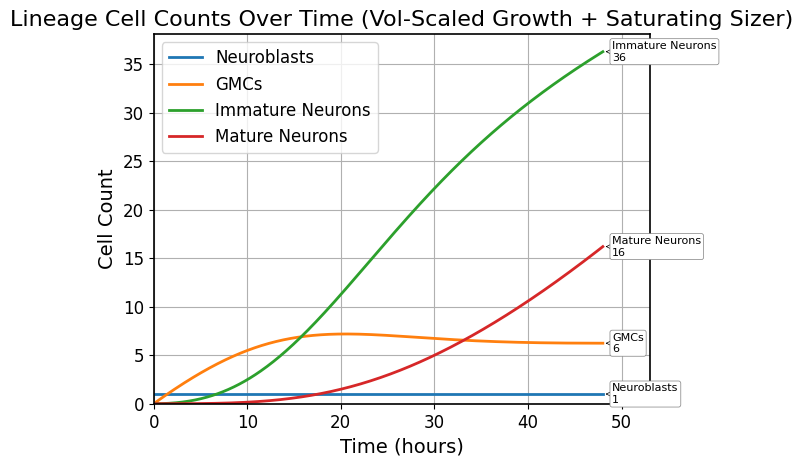

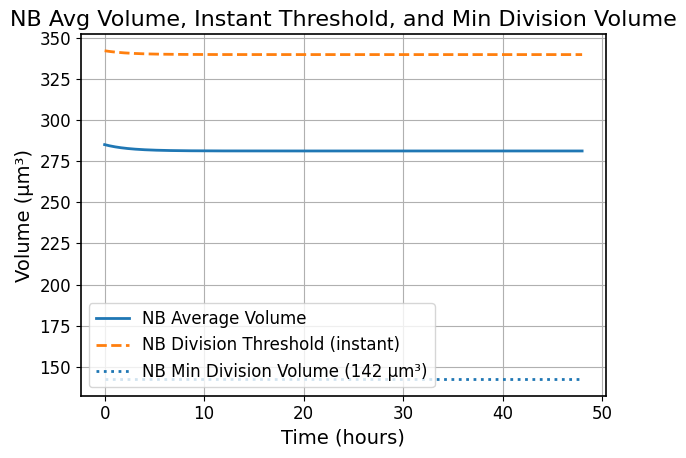

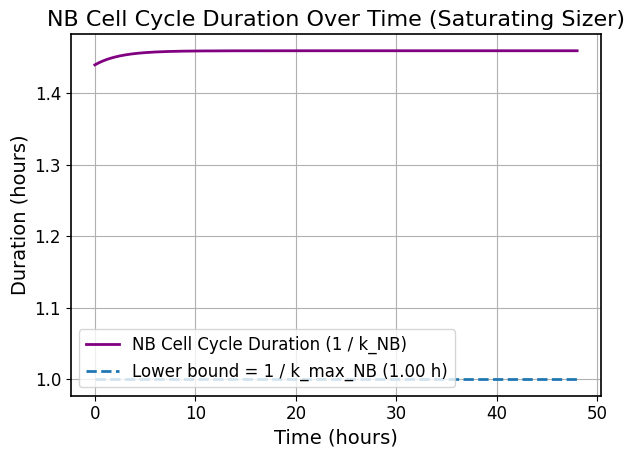

In [20]:
# --- WT params (volume-scaled growth + saturating sizer division) ---
nb_vol = 285                                # Initial neuroblast volume (µm³)

V_thresh_base = 1.2 * nb_vol                # Base NB threshold at V_ref
g_NB_base = nb_vol * 0.2 / 1.5              # NB base growth rate (volume/hr)
g_GMC     = (nb_vol * 1.2 * 0.2) / 9        # GMC growth rate (volume/hr)

V_thresh_GMC = (nb_vol * 1.2 * 0.2) * 2     # GMC division threshold volume (µm³)
k_max_NB  = 1.0                             # Max NB division rate (divisions/hr)
k_max_GMC = 1.0 / 8.0                       # Max GMC division rate (divisions/hr)
n         = 2                               # Exponent in the saturating sizer

sym_frac  = 0.0                             # Fraction of NB divisions that are symmetric
k_Neuron  = 1.0 / 48.0                      # Immature neuron maturation rate (1/hr)
V_floor_NB    = nb_vol / 2.0                # Min avg NB volume before division allowed

# NB growth rate and division threshold scaling parameters
V_ref         = nb_vol                      # Reference volume for NB growth/threshold scaling
alpha_growth  = 1.0                         # Growth sensitivity to NB volume
alpha_thresh  = 0.5                         # Threshold sensitivity to NB volume (small)

# Parameter order for the saturating model:
# (g_NB_base, g_GMC, k_Neuron, sym_frac,
#  V_thresh_base, V_thresh_GMC,
#  k_max_NB, k_max_GMC, n,
#  V_floor_NB, V_ref, alpha_growth, alpha_thresh)
params_vol_scaled_sat = [
    g_NB_base, g_GMC,
    k_Neuron,
    sym_frac,
    V_thresh_base, V_thresh_GMC,
    k_max_NB, k_max_GMC,
    n
]

# Initial conditions
# [N_NB, V_NB, N_GMC, V_GMC, N_ImNeuron, V_ImNeuron, N_MatNeuron, V_MatNeuron]
y0 = [1, nb_vol, 0, 0, 0, 0, 0, 0]

t_span = [0, 48]
t_eval = np.linspace(*t_span, 500)

# --- Solve ---
sol_vol_scaled = solve_ivp(
    neuroblast_model_volume_threshold_division_satpow,
    t_span, y0, t_eval=t_eval, args=(params_vol_scaled_sat,),
    rtol=1e-6, atol=1e-9
)

# ========== Plot 1: Cell counts ==========
fig, ax = plt.subplots()
labels  = ["Neuroblasts", "GMCs", "Immature Neurons", "Mature Neurons"]
indices = [0, 2, 4, 6]
y_data  = [sol_vol_scaled.y[i] for i in indices]

for y, label in zip(y_data, labels):
    ax.plot(sol_vol_scaled.t, y, label=label)

ax.set_xlim(0, sol_vol_scaled.t[-1] + 5)
ax.set_ylim(bottom=0)
try:
    annotate_final_values(ax, sol_vol_scaled.t, y_data, labels)
except NameError:
    pass
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Cell Count")
ax.set_title("Lineage Cell Counts Over Time (Vol-Scaled Growth + Saturating Sizer)")
ax.grid()
ax.legend()
plt.show()

# ========== Plot 2: NB avg volume vs threshold (+ floor) ==========
Vavg_NB = np.divide(sol_vol_scaled.y[1], sol_vol_scaled.y[0],
                    out=np.zeros_like(sol_vol_scaled.y[1]),
                    where=sol_vol_scaled.y[0] > 0)

# Instantaneous threshold over time (scaled to NB avg volume):
Vthresh_NB_t = V_thresh_base * (np.divide(Vavg_NB, V_ref,
                                          out=np.ones_like(Vavg_NB),
                                          where=V_ref > 0) ** alpha_thresh)

fig, ax = plt.subplots()
ax.plot(sol_vol_scaled.t, Vavg_NB, label="NB Average Volume", linewidth=2)
ax.plot(sol_vol_scaled.t, Vthresh_NB_t, '--', label="NB Division Threshold (instant)")
ax.hlines(V_floor_NB, sol_vol_scaled.t[0], sol_vol_scaled.t[-1],
          linestyles=":", label=f"NB Min Division Volume ({V_floor_NB:.0f} µm³)")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Volume (µm³)")
ax.set_title("NB Avg Volume, Instant Threshold, and Min Division Volume")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

# ========== Plot 3: NB cell-cycle duration (1 / k_NB) ==========
# Recompute Vavg and ratio
Vavg_NB = np.divide(sol_vol_scaled.y[1], sol_vol_scaled.y[0],
                    out=np.zeros_like(sol_vol_scaled.y[1]),
                    where=sol_vol_scaled.y[0] > 0)
ratio = np.divide(Vavg_NB, V_ref, out=np.ones_like(Vavg_NB), where=V_ref > 0)

# Instant effective threshold series for NBs
V_thresh_eff_series = V_thresh_base * (ratio ** alpha_thresh)

# Instantaneous NB division rate using saturating sizer:
with np.errstate(divide='ignore', invalid='ignore'):
    # core saturating term: min(1, (Vavg_NB / V_thresh_eff)^n)
    core = np.where(V_thresh_eff_series > 0,
                    (Vavg_NB / V_thresh_eff_series) ** n,
                    0.0)
    core = np.minimum(core, 1.0)
    k_NB_series = np.where(
        Vavg_NB >= V_floor_NB,
        k_max_NB * core,
        0.0
    )

# Cell-cycle duration = 1 / k_NB (NaN when k_NB = 0)
ccd_hazard = np.where(k_NB_series > 0, 1.0 / k_NB_series, np.nan)

fig, ax = plt.subplots()
ax.plot(sol_vol_scaled.t, ccd_hazard, color="purple", label="NB Cell Cycle Duration (1 / k_NB)")
ax.hlines(1.0 / k_max_NB, sol_vol_scaled.t[0], sol_vol_scaled.t[-1],
          linestyles="--", label=f"Lower bound = 1 / k_max_NB ({1.0/k_max_NB:.2f} h)")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Duration (hours)")
ax.set_title("NB Cell Cycle Duration Over Time (Saturating Sizer)")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

mudmut simulation

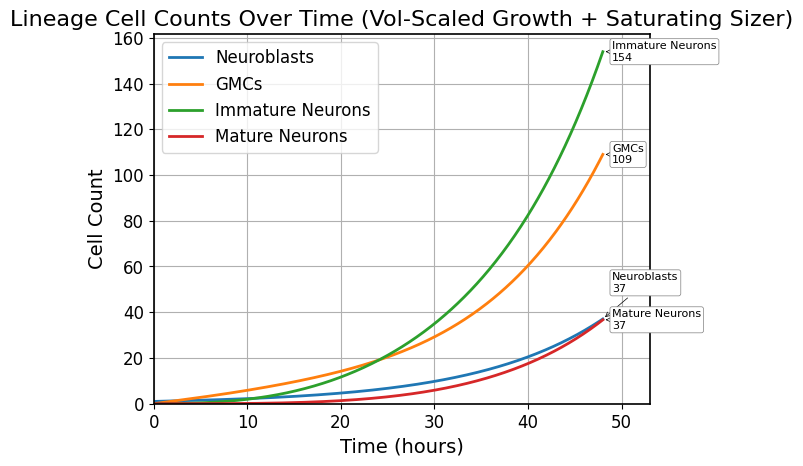

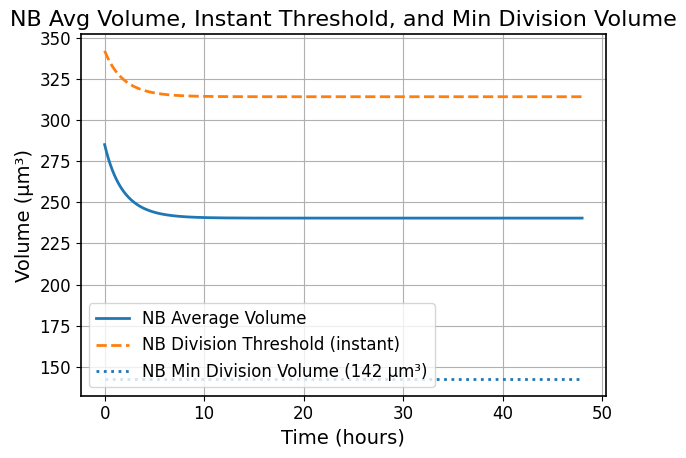

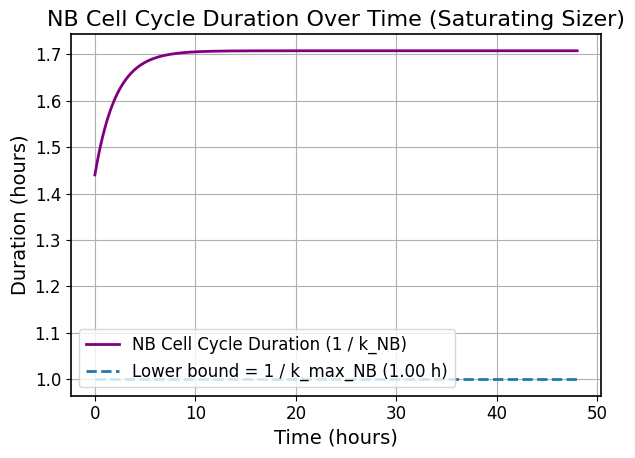

In [21]:
# --- mudmut params (volume-scaled growth + saturating sizer division) ---
nb_vol = 285                                # Initial neuroblast volume (µm³)

V_thresh_base = 1.2 * nb_vol                # Base NB threshold at V_ref
g_NB_base = nb_vol * 0.2 / 1.5              # NB base growth rate (volume/hr)
g_GMC     = (nb_vol * 1.2 * 0.2) / 9        # GMC growth rate (volume/hr)

V_thresh_GMC = (nb_vol * 1.2 * 0.2) * 2     # GMC division threshold volume (µm³)
k_max_NB  = 1.0                             # Max NB division rate (divisions/hr)
k_max_GMC = 1.0 / 8.0                       # Max GMC division rate (divisions/hr)
n         = 2                               # Exponent in the saturating sizer

sym_frac  = 0.15                           # Fraction of NB divisions that are symmetric
k_Neuron  = 1.0 / 48.0                      # Immature neuron maturation rate (1/hr)
V_floor_NB    = nb_vol / 2.0                # Min avg NB volume before division allowed

# NB growth rate and division threshold scaling parameters
V_ref         = nb_vol                      # Reference volume for NB growth/threshold scaling
alpha_growth  = 1.0                         # Growth sensitivity to NB volume
alpha_thresh  = 0.5                         # Threshold sensitivity to NB volume (small)

# Parameter order for the saturating model:
# (g_NB_base, g_GMC, k_Neuron, sym_frac,
#  V_thresh_base, V_thresh_GMC,
#  k_max_NB, k_max_GMC, n,
#  V_floor_NB, V_ref, alpha_growth, alpha_thresh)
params_vol_scaled_sat = [
    g_NB_base, g_GMC,
    k_Neuron,
    sym_frac,
    V_thresh_base, V_thresh_GMC,
    k_max_NB, k_max_GMC,
    n
]

# Initial conditions
# [N_NB, V_NB, N_GMC, V_GMC, N_ImNeuron, V_ImNeuron, N_MatNeuron, V_MatNeuron]
y0 = [1, nb_vol, 0, 0, 0, 0, 0, 0]

t_span = [0, 48]
t_eval = np.linspace(*t_span, 500)

# --- Solve ---
sol_vol_scaled = solve_ivp(
    neuroblast_model_volume_threshold_division_satpow,
    t_span, y0, t_eval=t_eval, args=(params_vol_scaled_sat,),
    rtol=1e-6, atol=1e-9
)

# ========== Plot 1: Cell counts ==========
fig, ax = plt.subplots()
labels  = ["Neuroblasts", "GMCs", "Immature Neurons", "Mature Neurons"]
indices = [0, 2, 4, 6]
y_data  = [sol_vol_scaled.y[i] for i in indices]

for y, label in zip(y_data, labels):
    ax.plot(sol_vol_scaled.t, y, label=label)

ax.set_xlim(0, sol_vol_scaled.t[-1] + 5)
ax.set_ylim(bottom=0)
try:
    annotate_final_values(ax, sol_vol_scaled.t, y_data, labels)
except NameError:
    pass
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Cell Count")
ax.set_title("Lineage Cell Counts Over Time (Vol-Scaled Growth + Saturating Sizer)")
ax.grid()
ax.legend()
plt.show()

# ========== Plot 2: NB avg volume vs threshold (+ floor) ==========
Vavg_NB = np.divide(sol_vol_scaled.y[1], sol_vol_scaled.y[0],
                    out=np.zeros_like(sol_vol_scaled.y[1]),
                    where=sol_vol_scaled.y[0] > 0)

# Instantaneous threshold over time (scaled to NB avg volume):
Vthresh_NB_t = V_thresh_base * (np.divide(Vavg_NB, V_ref,
                                          out=np.ones_like(Vavg_NB),
                                          where=V_ref > 0) ** alpha_thresh)

fig, ax = plt.subplots()
ax.plot(sol_vol_scaled.t, Vavg_NB, label="NB Average Volume", linewidth=2)
ax.plot(sol_vol_scaled.t, Vthresh_NB_t, '--', label="NB Division Threshold (instant)")
ax.hlines(V_floor_NB, sol_vol_scaled.t[0], sol_vol_scaled.t[-1],
          linestyles=":", label=f"NB Min Division Volume ({V_floor_NB:.0f} µm³)")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Volume (µm³)")
ax.set_title("NB Avg Volume, Instant Threshold, and Min Division Volume")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

# ========== Plot 3: NB cell-cycle duration (1 / k_NB) ==========
# Recompute Vavg and ratio
Vavg_NB = np.divide(sol_vol_scaled.y[1], sol_vol_scaled.y[0],
                    out=np.zeros_like(sol_vol_scaled.y[1]),
                    where=sol_vol_scaled.y[0] > 0)
ratio = np.divide(Vavg_NB, V_ref, out=np.ones_like(Vavg_NB), where=V_ref > 0)

# Instant effective threshold series for NBs
V_thresh_eff_series = V_thresh_base * (ratio ** alpha_thresh)

# Instantaneous NB division rate using saturating sizer:
with np.errstate(divide='ignore', invalid='ignore'):
    # core saturating term: min(1, (Vavg_NB / V_thresh_eff)^n)
    core = np.where(V_thresh_eff_series > 0,
                    (Vavg_NB / V_thresh_eff_series) ** n,
                    0.0)
    core = np.minimum(core, 1.0)
    k_NB_series = np.where(
        Vavg_NB >= V_floor_NB,
        k_max_NB * core,
        0.0
    )

# Cell-cycle duration = 1 / k_NB (NaN when k_NB = 0)
ccd_hazard = np.where(k_NB_series > 0, 1.0 / k_NB_series, np.nan)

fig, ax = plt.subplots()
ax.plot(sol_vol_scaled.t, ccd_hazard, color="purple", label="NB Cell Cycle Duration (1 / k_NB)")
ax.hlines(1.0 / k_max_NB, sol_vol_scaled.t[0], sol_vol_scaled.t[-1],
          linestyles="--", label=f"Lower bound = 1 / k_max_NB ({1.0/k_max_NB:.2f} h)")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Duration (hours)")
ax.set_title("NB Cell Cycle Duration Over Time (Saturating Sizer)")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

---

# Volume-Adder Neuroblast Growth Rate Scaled to Birth Volume

## Model Purpose

This model tests whether differences in NB birth volume alone can explain the reduced cell counts observed in mudmut NB colonies, under an adder-based cell-cycle control. The underlying hypothesis is:
- Adder control: NBs do not divide at a fixed size; instead, they must add a fixed volume ΔV to their birth volume before division occurs.
- Growth rate effect: Symmetric NB divisions in mudmut colonies produce daughter NBs with much smaller birth volumes than WT NBs. If NB growth rate scales with birth size, these smaller cells will grow more slowly, lengthening their cycles and reducing overall cell counts.

This formulation isolates the growth rate effect from any division-threshold scaling, as division depends only on volume added since birth, not on absolute cell size.


## Model Species
- $N_{\text{NB}}, V_{\text{NB}}$ — Neuroblast (NB) count & total NB volume
- $S_{\text{NB}}$ — Sum of NB birth volumes (bookkeeping variable for adder control)
- $N_{\text{GMC}}, V_{\text{GMC}}$ — GMC count & total GMC volume
- $N_{\text{ImNeuron}}, V_{\text{ImNeuron}}$ — Immature neuron count & volume
- $N_{\text{MatNeuron}}, V_{\text{MatNeuron}}$ — Mature neuron count & volume

## Model Parameters
- $g_{\text{NB,base}}$ — Base NB growth rate at reference birth size
- $g_{\text{GMC}}$ — GMC growth rate
- $k_{\text{Neuron}}$ — Immature neuron → mature neuron maturation rate
- $\text{sym\_frac}$ — Fraction of symmetric NB divisions
- $k_{\text{max,NB}}$ — Maximum NB division rate
- $k_{\text{max,GMC}}$ — Maximum GMC division rate
- $n$ — Adder sharpness exponent in division control
- $\Delta V_{\text{add,NB}}$ — NB adder target (volume to add before division)
- $\Delta V_{\text{add,GMC}}$ — GMC adder target
- $V_{\text{ref}}$ — Reference NB birth volume for growth scaling
- $\alpha_{\text{birth}}$ — Exponent for how NB growth rate scales with birth size

## Average Volumes and Birth Volumes
- Average NB volume: $\bar{V}_{\text{NB}} = V_{\text{NB}} / N_{\text{NB}}$
- Average GMC volume: $\bar{V}_{\text{GMC}} = V_{\text{GMC}} / N_{\text{GMC}}$
- Average NB birth volume: $\bar{B}_{\text{NB}} = S_{\text{NB}} / N_{\text{NB}}$

The added volumes are:
$$
\Delta V_{\text{NB}} = \max\!\big(0, \bar{V}_{\text{NB}} - \bar{B}_{\text{NB}}\big),
\qquad
\Delta V_{\text{GMC}} = \max\!\big(0, \bar{V}_{\text{GMC}}\big)
$$

## Growth Rate Scaling
NB growth rate scales with average birth volume relative to a reference:
$$
g_{\text{NB,eff}} = g_{\text{NB,base}} \cdot \left(\frac{\bar{B}_{\text{NB}}}{V_{\text{ref}}}\right)^{\alpha_{\text{birth}}}
$$
- If $\bar{B}_{\text{NB}} < V_{\text{ref}}$ and $\alpha_{\text{birth}} > 0$, NB growth is slower.

## Division Rates — Adder Logic (saturating power law)

Division readiness depends on **added volume since birth** via a capped power law:
$$
k_{\text{NB}} \;=\; k_{\text{max,NB}} \cdot \min\!\left(1,\;\left(\frac{\Delta V_{\text{NB}}}{\Delta V_{\text{add,NB}}}\right)^{n}\right),
$$
$$
k_{\text{GMC}} \;=\; k_{\text{max,GMC}} \cdot \min\!\left(1,\;\left(\frac{\Delta V_{\text{GMC}}}{\Delta V_{\text{add,GMC}}}\right)^{n}\right).
$$

Where:
- $\Delta V_{\text{NB}} = \max\!\big(0,\,\bar{V}_{\text{NB}} - \bar{B}_{\text{NB}}\big)$ is the NB volume added since birth,
- $\Delta V_{\text{GMC}} = \max\!\big(0,\,\bar{V}_{\text{GMC}}\big)$ (GMCs start with negligible birth volume in this model).

- The exponent $n$ sets sharpness; rates increase as $(\Delta V / \Delta V_{\text{add}})^{n}$ when below target and **saturate at** $k_{\max}$ once $\Delta V \ge \Delta V_{\text{add}}$.

## Partitioning of NB Divisions

Same as in the sizer model:
$$
\text{sym\_divs} = \text{sym\_frac} \cdot k_{\text{NB}} \cdot N_{\text{NB}}, \quad
\text{asym\_divs} = (1 - \text{sym\_frac}) \cdot k_{\text{NB}} \cdot N_{\text{NB}}
$$

## ODEs

**NB Birth-Volume Sum $(S_{\text{NB}})$**
Remove parent’s birth volume at division; add daughters’ birth volumes:
$$
\frac{dS_{\text{NB}}}{dt}
= -k_{\text{NB}} \cdot N_{\text{NB}} \cdot \bar{B}_{\text{NB}}
+ \text{sym\_divs} \cdot \bar{V}_{\text{NB}}
+ \text{asym\_divs} \cdot \big(0.8 \cdot \bar{V}_{\text{NB}}\big)
$$

**Neuroblast Count**
$$
\frac{dN_{\text{NB}}}{dt} = \text{sym\_divs}
$$

**Neuroblast Volume**
$$
\frac{dV_{\text{NB}}}{dt}
= g_{\text{NB,eff}} \cdot N_{\text{NB}}
- 0.2 \cdot \text{asym\_divs} \cdot \bar{V}_{\text{NB}}
$$

**GMC Count**
$$
\frac{dN_{\text{GMC}}}{dt}
= \text{asym\_divs}
- k_{\text{GMC}} \cdot N_{\text{GMC}}
$$

**GMC Volume**
$$
\frac{dV_{\text{GMC}}}{dt}
= g_{\text{GMC}} \cdot N_{\text{GMC}}
+ 0.2 \cdot \text{asym\_divs} \cdot \bar{V}_{\text{NB}}
- k_{\text{GMC}} \cdot N_{\text{GMC}} \cdot \bar{V}_{\text{GMC}}
$$

**Immature Neuron Count**
$$
\frac{dN_{\text{ImNeuron}}}{dt}
= 2 \cdot k_{\text{GMC}} \cdot N_{\text{GMC}}
- k_{\text{Neuron}} \cdot N_{\text{ImNeuron}}
$$

**Immature Neuron Volume**
$$
\frac{dV_{\text{ImNeuron}}}{dt}
= k_{\text{GMC}} \cdot N_{\text{GMC}} \cdot \bar{V}_{\text{GMC}}
- k_{\text{Neuron}} \cdot N_{\text{ImNeuron}} \cdot \bar{V}_{\text{ImNeuron}}
$$

**Mature Neuron Count**
$$
\frac{dN_{\text{MatNeuron}}}{dt}
= k_{\text{Neuron}} \cdot N_{\text{ImNeuron}}
$$

**Mature Neuron Volume**
$$
\frac{dV_{\text{MatNeuron}}}{dt}
= k_{\text{Neuron}} \cdot N_{\text{ImNeuron}} \cdot \bar{V}_{\text{ImNeuron}}
$$

In [50]:
def neuroblast_model_volume_saturating_powerlaw_birth_scaled_growth(t, y, params):
    """
    Neuroblast model with saturating power-law division dynamics
    and NB growth rate scaled by average NB birth volume.

    State vector:
        y = [N_NB, V_NB, N_GMC, V_GMC, N_Im, V_Im, N_Mat, V_Mat, S_NB]
            N_*  : cell counts
            V_*  : total volumes
            S_NB : sum of NB birth volumes (bookkeeping for division thresholds)

    Parameters (list/tuple in this order):
        g_NB_base    : base NB growth rate (volume/hour)
        g_GMC        : GMC growth rate (volume/hour)
        k_Neuron     : maturation rate (1/hour)
        sym_frac     : fraction of NB divisions that are symmetric [0..1]
        k_max_NB     : max NB division rate (1/hour)
        k_max_GMC    : max GMC division rate (1/hour)
        n            : exponent for saturating power-law division dynamics
        dV_add_NB    : NB characteristic added-volume scale (reference volume increment)
        dV_add_GMC   : GMC characteristic added-volume scale
        V_ref        : reference birth volume for NB growth scaling
        alpha_birth  : exponent for NB birth-volume growth scaling
                    (>0 reduces growth when birth volume is smaller than V_ref)

    Notes:
    - NB effective growth rate:
            g_NB_eff = g_NB_base * (Bavg_NB / V_ref)^alpha_birth
    - Division rates:
            k = k_max * min(1, (ΔV / ΔV_add)^n)
        where ΔV is added volume since birth. This produces a
        saturating power-law increase with ΔV, capped at k_max.
    - Bookkeeping:
            S_NB tracks NB birth volumes so that ΔV_NB can be
            computed as Vavg_NB - Bavg_NB.
    """
    (N_NB, V_NB,
     N_GMC, V_GMC,
     N_Im,  V_Im,
     N_Mat, V_Mat,
     S_NB) = y

    (g_NB_base, g_GMC,
     k_Neuron,
     sym_frac,
     k_max_NB, k_max_GMC,
     n,
     dV_add_NB, dV_add_GMC,
     V_ref, alpha_birth) = params

    # --- Averages with guards ---
    Vavg_NB = V_NB / N_NB if N_NB > 0 else 0.0
    Vavg_GMC = V_GMC / N_GMC if N_GMC > 0 else 0.0
    Vavg_Im = V_Im / N_Im if N_Im > 0 else 0.0

    Bavg_NB = S_NB / N_NB if N_NB > 0 else 0.0          # average NB birth volume

    # --- NB growth scaling by average birth volume ---
    if V_ref > 0 and Bavg_NB > 0:
        scale_birth = (Bavg_NB / V_ref) ** alpha_birth
    else:
        scale_birth = 0.0 if alpha_birth > 0 else 1.0  # if no NBs and alpha>0, growth effectively off
    g_NB_eff = g_NB_base * scale_birth

    # --- Adder logic: added volume since birth ---
    dV_NB = max(0.0, Vavg_NB - Bavg_NB)
    dV_GMC = max(0.0, Vavg_GMC - 0.0)

    # --- Division rates (saturating power in added volume; capped at k_max) ---
    k_NB = 0.0
    k_GMC = 0.0
    if N_NB > 0 and dV_add_NB > 0:
        core_NB = (dV_NB / dV_add_NB)**n if dV_NB > 0 else 0.0
        core_NB = 1.0 if core_NB >= 1.0 else core_NB
        k_NB = k_max_NB * core_NB

    if N_GMC > 0 and dV_add_GMC > 0:
        core_GMC = (dV_GMC / dV_add_GMC)**n if dV_GMC > 0 else 0.0
        core_GMC = 1.0 if core_GMC >= 1.0 else core_GMC
        k_GMC = k_max_GMC * core_GMC

    # --- Division fluxes ---
    sym_divs  = sym_frac * k_NB * N_NB
    asym_divs = (1.0 - sym_frac) * k_NB * N_NB

    # --- Neuroblasts ---
    dN_NB = sym_divs
    dV_NB = (
        g_NB_eff * N_NB
        - k_NB * N_NB * Vavg_NB       # remove parent NB volumes on any NB division
        + sym_divs * Vavg_NB          # add birth volume of two NB daughters (net +Vavg_NB)
        + asym_divs * 0.8 * Vavg_NB   # add birth volume of NB daughter in asymmetric division
    )
    # Birth-volume bookkeeping for NB (remove parents' birth volume, add daughters')
    dS_NB = (
        - k_NB * N_NB * Bavg_NB              # remove parents' birth volume
        + sym_divs * Vavg_NB                 # add two NB daughters' birth volumes: net +Vavg_NB
        + asym_divs * (0.8 * Vavg_NB)        # add NB daughter (0.8 * Vavg_NB) in asymmetric division
    )

    # --- GMCs ---
    dN_GMC = asym_divs - k_GMC * N_GMC
    dV_GMC = (
        g_GMC * N_GMC
        + asym_divs * 0.2 * Vavg_NB
        - k_GMC * N_GMC * Vavg_GMC
    )

    # --- Neurons ---
    dN_Im  = 2.0 * k_GMC * N_GMC - k_Neuron * N_Im
    dV_Im  = k_GMC * N_GMC * Vavg_GMC - k_Neuron * N_Im * Vavg_Im

    dN_Mat = k_Neuron * N_Im
    dV_Mat = k_Neuron * N_Im * Vavg_Im

    return [
        dN_NB, dV_NB,
        dN_GMC, dV_GMC,
        dN_Im,  dV_Im,
        dN_Mat, dV_Mat,
        dS_NB
    ]

WT model

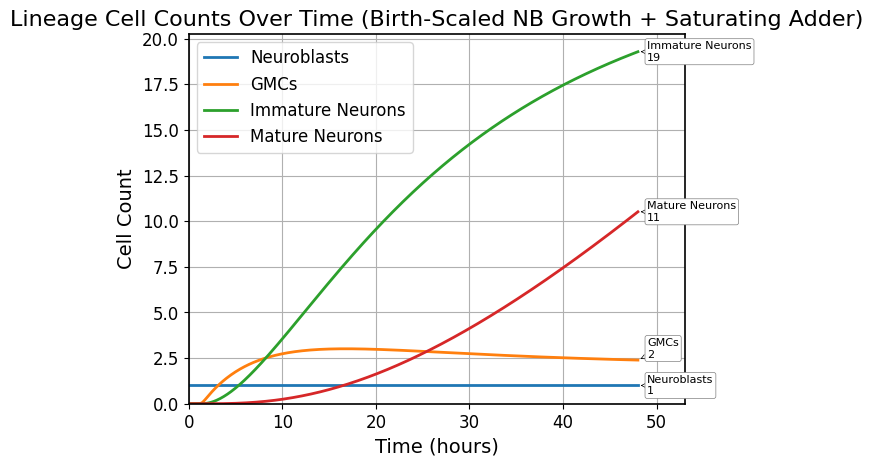

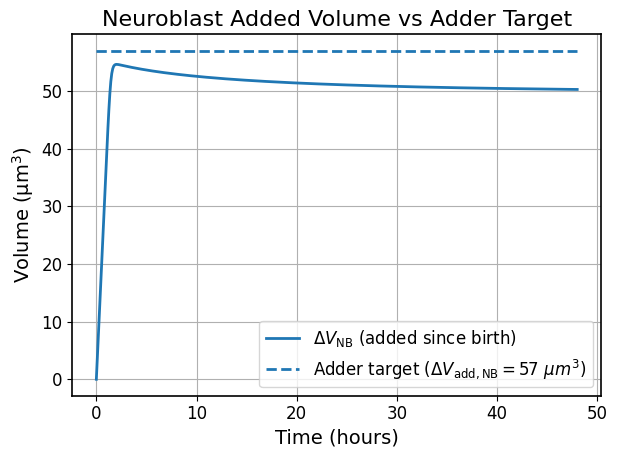

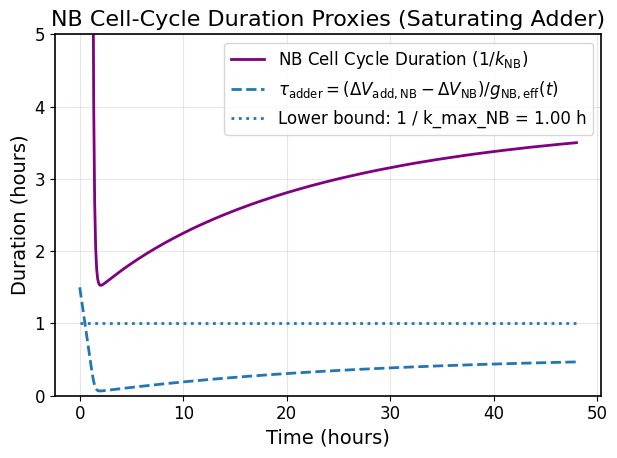

In [57]:
# --- WT params (birth-scaled NB growth + saturating adder division) ---
nb_vol = 285                                # Initial neuroblast volume (µm³)

g_NB_base = nb_vol * 0.2 / 1.5              # NB base growth rate (volume/hr)
g_GMC     = (nb_vol * 1.2 * 0.2) / 9        # GMC growth rate (volume/hr)

k_max_NB  = 1.0                             # Max NB division rate (divisions/hr)
k_max_GMC = 1.0 / 8.0                       # Max GMC division rate (divisions/hr)
n         = 10                               # Exponent in the saturating adder

sym_frac  = 0.0                             # Fraction of NB divisions that are symmetric
k_Neuron  = 1.0 / 48.0                      # Immature neuron maturation rate (1/hr)

# Adder targets (volumes to add since birth to reach k_max)
dV_add_NB  = 0.20 * nb_vol                  # NB must add ~20% of reference NB volume
dV_add_GMC = 0.24 * nb_vol                  # GMC must add ~24% of reference NB volume

# NB growth rate scaling by birth size
V_ref        = nb_vol                        # Reference NB birth volume
alpha_birth  = 3.0                           # >0 → smaller-at-birth NBs grow more slowly

# Parameter order for this model:
# (g_NB_base, g_GMC, k_Neuron, sym_frac,
#  k_max_NB, k_max_GMC, n,
#  dV_add_NB, dV_add_GMC,
#  V_ref, alpha_birth)
params_adder_sat = [
    g_NB_base, g_GMC,
    k_Neuron,
    sym_frac,
    k_max_NB, k_max_GMC,
    n,
    dV_add_NB, dV_add_GMC,
    V_ref, alpha_birth
]

# Initial conditions
# y = [N_NB, V_NB, N_GMC, V_GMC, N_Im, V_Im, N_Mat, V_Mat, S_NB]
# Start with one NB whose birth volume = nb_vol, so S_NB = nb_vol.
y0 = [1, nb_vol, 0, 0, 0, 0, 0, 0, nb_vol]

t_span = [0, 48]
t_eval = np.linspace(*t_span, 500)

# --- Solve ---
sol_adder = solve_ivp(
    neuroblast_model_volume_saturating_powerlaw_birth_scaled_growth,
    t_span, y0, t_eval=t_eval, args=(params_adder_sat,),
    rtol=1e-6, atol=1e-9
)

# ========== Plot 1: Cell counts ==========
fig, ax = plt.subplots()
labels  = ["Neuroblasts", "GMCs", "Immature Neurons", "Mature Neurons"]
indices = [0, 2, 4, 6]
y_data  = [sol_adder.y[i] for i in indices]

for y, label in zip(y_data, labels):
    ax.plot(sol_adder.t, y, label=label)

ax.set_xlim(0, sol_adder.t[-1] + 5)
ax.set_ylim(bottom=0)
try:
    annotate_final_values(ax, sol_adder.t, y_data, labels)
except NameError:
    pass
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Cell Count")
ax.set_title("Lineage Cell Counts Over Time (Birth-Scaled NB Growth + Saturating Adder)")
ax.grid()
ax.legend()
plt.show()

# ========== Plot 2: NB added volume (ΔV) vs adder target ==========
Vavg_NB = np.divide(sol_adder.y[1], sol_adder.y[0],
                    out=np.zeros_like(sol_adder.y[1]),
                    where=sol_adder.y[0] > 0)
Bavg_NB = np.divide(sol_adder.y[8], sol_adder.y[0],
                    out=np.zeros_like(sol_adder.y[8]),
                    where=sol_adder.y[0] > 0)
dV_NB_series = np.maximum(0.0, Vavg_NB - Bavg_NB)

fig, ax = plt.subplots()
ax.plot(sol_adder.t, dV_NB_series, label=r"$\Delta V_{\mathrm{NB}}$ (added since birth)", linewidth=2)
ax.hlines(dV_add_NB, sol_adder.t[0], sol_adder.t[-1], linestyles="--",
          label=rf"Adder target ($\Delta V_{{\mathrm{{add,NB}}}}={dV_add_NB:.0f}\ \mu m^3$)")
ax.set_xlabel("Time (hours)")
ax.set_ylabel(r"Volume (µm$^3$)")
ax.set_title("Neuroblast Added Volume vs Adder Target")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

# ========== Plot 3: NB cell-cycle duration proxies (robust) ==========

# Recompute the series we need
Vavg_NB = np.divide(sol_adder.y[1], sol_adder.y[0],
                    out=np.zeros_like(sol_adder.y[1]),
                    where=sol_adder.y[0] > 0)
Bavg_NB = np.divide(sol_adder.y[8], sol_adder.y[0],
                    out=np.zeros_like(sol_adder.y[8]),
                    where=sol_adder.y[0] > 0)
dV_NB_series = np.maximum(0.0, Vavg_NB - Bavg_NB)

# Birth-scaled NB growth rate g_NB_eff(t) for τ_adder proxy
g_NB_eff_series = g_NB_base * np.where(
    V_ref > 0,
    np.power(np.divide(Bavg_NB, V_ref,
                       out=np.zeros_like(Bavg_NB), where=V_ref > 0), alpha_birth),
    1.0
)

# k_NB(t) = k_max_NB * min(1, (ΔV_NB / dV_add_NB)^n)
with np.errstate(divide='ignore', invalid='ignore'):
    core = np.where(dV_add_NB > 0, (dV_NB_series / dV_add_NB) ** n, 0.0)
    core = np.minimum(core, 1.0)
    k_NB_series = k_max_NB * core

# ---- Robust masking to avoid the initial spike and divide-by-zero ----
eps_frac = 1e-4   # mask very-early phase: ΔV < eps_frac * ΔV_add
eps_k    = 1e-9   # numerical floor for k to avoid 1/0

valid = (dV_NB_series >= (eps_frac * dV_add_NB)) & (k_NB_series > eps_k)

ccd_hazard = np.full_like(k_NB_series, np.nan, dtype=float)
ccd_hazard[valid] = 1.0 / k_NB_series[valid]

# τ_adder proxy = remaining adder / current growth rate
# τ_adder = max(0, ΔV_add - ΔV) / g_NB_eff, masked when g_NB_eff is tiny
tau_adder = np.full_like(dV_NB_series, np.nan, dtype=float)
mask_g = g_NB_eff_series > eps_k
tau_adder[mask_g] = np.maximum(0.0, dV_add_NB - dV_NB_series[mask_g]) / g_NB_eff_series[mask_g]

fig, ax = plt.subplots()
ax.plot(sol_adder.t, ccd_hazard, color="purple",
        label=r"NB Cell Cycle Duration ($1/k_{\mathrm{NB}}$)", linewidth=2)
ax.plot(sol_adder.t, tau_adder, "--",
       label=r"$\tau_{\mathrm{adder}} = (\Delta V_{\mathrm{add,NB}}-\Delta V_{\mathrm{NB}})/g_{\mathrm{NB,eff}}(t)$")

ax.hlines(1.0 / k_max_NB, sol_adder.t[0], sol_adder.t[-1],
          linestyles=":", label=f"Lower bound: 1 / k_max_NB = {1.0/k_max_NB:.2f} h")

ax.set_xlabel("Time (hours)")
ax.set_ylabel("Duration (hours)")
ax.set_ylim(0, 5)
ax.set_title("NB Cell-Cycle Duration Proxies (Saturating Adder)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

mudmut Simulation

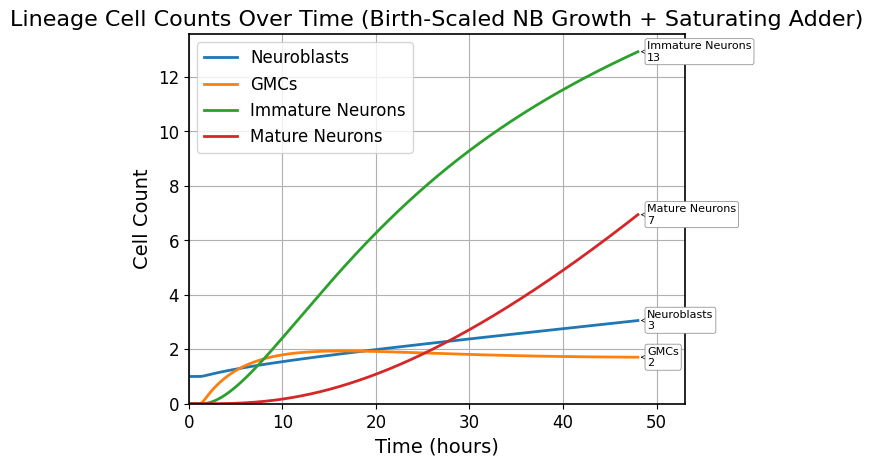

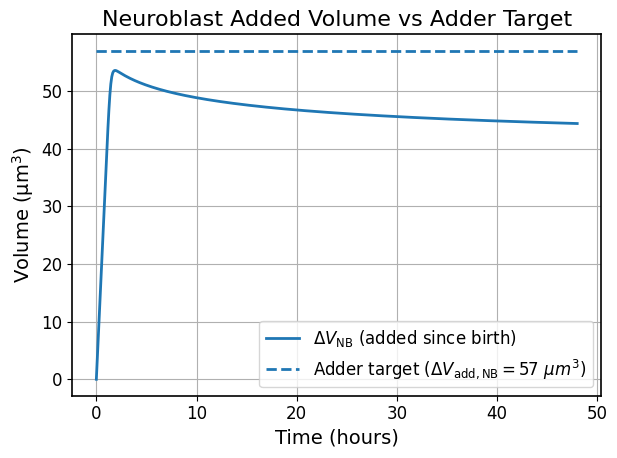

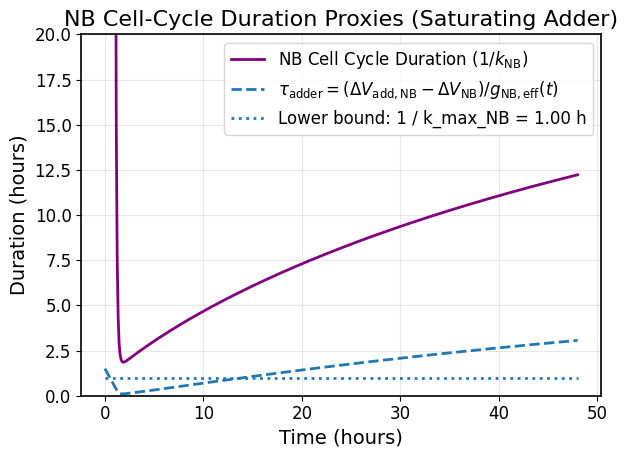

In [76]:
# --- WT params (birth-scaled NB growth + saturating adder division) ---
nb_vol = 285                                # Initial neuroblast volume (µm³)

g_NB_base = nb_vol * 0.2 / 1.5              # NB base growth rate (volume/hr)
g_GMC     = (nb_vol * 1.2 * 0.2) / 9        # GMC growth rate (volume/hr)

k_max_NB  = 1.0                             # Max NB division rate (divisions/hr)
k_max_GMC = 1.0 / 8.0                       # Max GMC division rate (divisions/hr)
n         = 10                               # Exponent in the saturating adder

sym_frac  = 0.15                            # Fraction of NB divisions that are symmetric
k_Neuron  = 1.0 / 48.0                      # Immature neuron maturation rate (1/hr)

# Adder targets (volumes to add since birth to reach k_max)
dV_add_NB  = 0.20 * nb_vol                  # NB must add ~20% of reference NB volume
dV_add_GMC = 0.24 * nb_vol                  # GMC must add ~24% of reference NB volume

# NB growth rate scaling by birth size
V_ref        = nb_vol                        # Reference NB birth volume
alpha_birth  = 3.0                           # >0 → smaller-at-birth NBs grow more slowly

# Parameter order for this model:
# (g_NB_base, g_GMC, k_Neuron, sym_frac,
#  k_max_NB, k_max_GMC, n,
#  dV_add_NB, dV_add_GMC,
#  V_ref, alpha_birth)
params_adder_sat = [
    g_NB_base, g_GMC,
    k_Neuron,
    sym_frac,
    k_max_NB, k_max_GMC,
    n,
    dV_add_NB, dV_add_GMC,
    V_ref, alpha_birth
]

# Initial conditions
# y = [N_NB, V_NB, N_GMC, V_GMC, N_Im, V_Im, N_Mat, V_Mat, S_NB]
# Start with one NB whose birth volume = nb_vol, so S_NB = nb_vol.
y0 = [1, nb_vol, 0, 0, 0, 0, 0, 0, nb_vol]

t_span = [0, 48]
t_eval = np.linspace(*t_span, 500)

# --- Solve ---
sol_adder = solve_ivp(
    neuroblast_model_volume_saturating_powerlaw_birth_scaled_growth,
    t_span, y0, t_eval=t_eval, args=(params_adder_sat,),
    rtol=1e-6, atol=1e-9
)

# ========== Plot 1: Cell counts ==========
fig, ax = plt.subplots()
labels  = ["Neuroblasts", "GMCs", "Immature Neurons", "Mature Neurons"]
indices = [0, 2, 4, 6]
y_data  = [sol_adder.y[i] for i in indices]

for y, label in zip(y_data, labels):
    ax.plot(sol_adder.t, y, label=label)

ax.set_xlim(0, sol_adder.t[-1] + 5)
ax.set_ylim(bottom=0)
try:
    annotate_final_values(ax, sol_adder.t, y_data, labels)
except NameError:
    pass
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Cell Count")
ax.set_title("Lineage Cell Counts Over Time (Birth-Scaled NB Growth + Saturating Adder)")
ax.grid()
ax.legend()
plt.show()

# ========== Plot 2: NB added volume (ΔV) vs adder target ==========
Vavg_NB = np.divide(sol_adder.y[1], sol_adder.y[0],
                    out=np.zeros_like(sol_adder.y[1]),
                    where=sol_adder.y[0] > 0)
Bavg_NB = np.divide(sol_adder.y[8], sol_adder.y[0],
                    out=np.zeros_like(sol_adder.y[8]),
                    where=sol_adder.y[0] > 0)
dV_NB_series = np.maximum(0.0, Vavg_NB - Bavg_NB)

fig, ax = plt.subplots()
ax.plot(sol_adder.t, dV_NB_series, label=r"$\Delta V_{\mathrm{NB}}$ (added since birth)", linewidth=2)
ax.hlines(dV_add_NB, sol_adder.t[0], sol_adder.t[-1], linestyles="--",
          label=rf"Adder target ($\Delta V_{{\mathrm{{add,NB}}}}={dV_add_NB:.0f}\ \mu m^3$)")
ax.set_xlabel("Time (hours)")
ax.set_ylabel(r"Volume (µm$^3$)")
ax.set_title("Neuroblast Added Volume vs Adder Target")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

# ========== Plot 3: NB cell-cycle duration proxies (robust) ==========

# Recompute the series we need
Vavg_NB = np.divide(sol_adder.y[1], sol_adder.y[0],
                    out=np.zeros_like(sol_adder.y[1]),
                    where=sol_adder.y[0] > 0)
Bavg_NB = np.divide(sol_adder.y[8], sol_adder.y[0],
                    out=np.zeros_like(sol_adder.y[8]),
                    where=sol_adder.y[0] > 0)
dV_NB_series = np.maximum(0.0, Vavg_NB - Bavg_NB)

# Birth-scaled NB growth rate g_NB_eff(t) for τ_adder proxy
g_NB_eff_series = g_NB_base * np.where(
    V_ref > 0,
    np.power(np.divide(Bavg_NB, V_ref,
                       out=np.zeros_like(Bavg_NB), where=V_ref > 0), alpha_birth),
    1.0
)

# k_NB(t) = k_max_NB * min(1, (ΔV_NB / dV_add_NB)^n)
with np.errstate(divide='ignore', invalid='ignore'):
    core = np.where(dV_add_NB > 0, (dV_NB_series / dV_add_NB) ** n, 0.0)
    core = np.minimum(core, 1.0)
    k_NB_series = k_max_NB * core

# ---- Robust masking to avoid the initial spike and divide-by-zero ----
eps_frac = 1e-4   # mask very-early phase: ΔV < eps_frac * ΔV_add
eps_k    = 1e-9   # numerical floor for k to avoid 1/0

valid = (dV_NB_series >= (eps_frac * dV_add_NB)) & (k_NB_series > eps_k)

ccd_hazard = np.full_like(k_NB_series, np.nan, dtype=float)
ccd_hazard[valid] = 1.0 / k_NB_series[valid]

# τ_adder proxy = remaining adder / current growth rate
# τ_adder = max(0, ΔV_add - ΔV) / g_NB_eff, masked when g_NB_eff is tiny
tau_adder = np.full_like(dV_NB_series, np.nan, dtype=float)
mask_g = g_NB_eff_series > eps_k
tau_adder[mask_g] = np.maximum(0.0, dV_add_NB - dV_NB_series[mask_g]) / g_NB_eff_series[mask_g]

fig, ax = plt.subplots()
ax.plot(sol_adder.t, ccd_hazard, color="purple",
        label=r"NB Cell Cycle Duration ($1/k_{\mathrm{NB}}$)", linewidth=2)
ax.plot(sol_adder.t, tau_adder, "--",
       label=r"$\tau_{\mathrm{adder}} = (\Delta V_{\mathrm{add,NB}}-\Delta V_{\mathrm{NB}})/g_{\mathrm{NB,eff}}(t)$")

ax.hlines(1.0 / k_max_NB, sol_adder.t[0], sol_adder.t[-1],
          linestyles=":", label=f"Lower bound: 1 / k_max_NB = {1.0/k_max_NB:.2f} h")

ax.set_xlabel("Time (hours)")
ax.set_ylabel("Duration (hours)")
ax.set_ylim(0, 20)
ax.set_title("NB Cell-Cycle Duration Proxies (Saturating Adder)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Conclusion:
- Even with a very high n (exponent in the saturating adder, so the NB division rate is very low until the added volume is close to the adder target), the added volume since birth drifts downward over time. This occurs because each division resets the birth volume reference, and when growth is scaled by birth size, smaller-than-reference birth volumes lead to systematically reduced added volumes.
- This drift is an emergent property of the coupling between the adder reset and the birth-volume–scaled growth
- When alpha_birth $ \geq 3 $, mudmut lineages have fewer cells than WT lineages. However, in those conditions WT lineages also have fewer cells than expected overall.
- When alpha_birth $ < 3 $, mudmut lineages have more cells than WT lineages.

---

In [64]:
def neuroblast_model_adder_windowed_hazard_birth_scaled_growth_with_SGMC(t, y, params):
    """
    Adder model with:
      • NB growth rate scaled by average NB birth volume, and
      • windowed (Gaussian) division hazards centered at the adder targets
      • GMC adder uses its own birth-baseline sum S_GMC (cohort-corrected).

    State vector:
        y = [N_NB, V_NB, N_GMC, V_GMC, N_Im, V_Im, N_Mat, V_Mat, S_NB, S_GMC]
            N_*    : cell counts
            V_*    : total volumes
            S_NB   : sum of NB birth volumes (for NB adder)
            S_GMC  : sum of GMC birth volumes (for GMC adder)

    Parameters (list/tuple in this order):
        g_NB_base, g_GMC, k_Neuron, sym_frac,
        k_max_NB, k_max_GMC,
        dV_add_NB, dV_add_GMC,
        sigma_NB, sigma_GMC,
        V_ref, alpha_birth

    Notes:
      - NB effective growth: g_NB_eff = g_NB_base * (Bavg_NB / V_ref)^{alpha_birth}
      - Windowed hazards (Gaussian bump at ΔV_add):
            k = k_max * exp( -0.5 * ((ΔV - ΔV_add)/(σ * ΔV_add))^2 )
        with σ = sigma_* (dimensionless, so σ * ΔV_add has units of volume).
      - Adder bookkeeping:
            ΔV_NB  = max(0, Vavg_NB  - Bavg_NB),   Bavg_NB  = S_NB  / N_NB
            ΔV_GMC = max(0, Vavg_GMC - Bavg_GMC),  Bavg_GMC = S_GMC / N_GMC
        S_NB and S_GMC remove parents' birth baselines on division and add
        daughters' birth baselines created at division.
    """
    import numpy as np

    # ---------- unpack state ----------
    (N_NB, V_NB,
     N_GMC, V_GMC,
     N_Im,  V_Im,
     N_Mat, V_Mat,
     S_NB, S_GMC) = y

    # ---------- unpack params ----------
    (g_NB_base, g_GMC,
     k_Neuron,
     sym_frac,
     k_max_NB, k_max_GMC,
     dV_add_NB, dV_add_GMC,
     sigma_NB, sigma_GMC,
     V_ref, alpha_birth) = params

    # ---------- averages (guard zeros) ----------
    Vavg_NB  = V_NB  / N_NB  if N_NB  > 0 else 0.0
    Vavg_GMC = V_GMC / N_GMC if N_GMC > 0 else 0.0
    Vavg_Im  = V_Im  / N_Im  if N_Im  > 0 else 0.0

    Bavg_NB  = S_NB  / N_NB  if N_NB  > 0 else 0.0
    Bavg_GMC = S_GMC / N_GMC if N_GMC > 0 else 0.0

    # ---------- NB growth scaling by birth size ----------
    if V_ref > 0 and Bavg_NB > 0:
        scale_birth = (Bavg_NB / V_ref) ** alpha_birth
    else:
        scale_birth = 0.0 if alpha_birth > 0 else 1.0
    g_NB_eff = g_NB_base * scale_birth

    # ---------- adder signals (added since birth) ----------
    dV_NB  = max(0.0, Vavg_NB  - Bavg_NB)
    dV_GMC = max(0.0, Vavg_GMC - Bavg_GMC)

    # ---------- windowed (Gaussian) division hazards ----------
    def windowed_hazard(dV, dV_add, kmax, sigma):
        if (dV_add is None) or (dV_add <= 0) or (sigma is None) or (sigma <= 0):
            return 0.0
        x = (dV - dV_add) / (sigma * dV_add)   # dimensionless deviation from target
        return float(kmax * np.exp(-0.5 * x * x))

    k_NB  = windowed_hazard(dV_NB,  dV_add_NB,  k_max_NB,  sigma_NB)  if N_NB  > 0 else 0.0
    k_GMC = windowed_hazard(dV_GMC, dV_add_GMC, k_max_GMC, sigma_GMC) if N_GMC > 0 else 0.0

    # ---------- division fluxes ----------
    sym_divs  = sym_frac * k_NB * N_NB
    asym_divs = (1.0 - sym_frac) * k_NB * N_NB

    # ---------- NB dynamics ----------
    dN_NB = sym_divs
    dV_NB = (
        g_NB_eff * N_NB
        - k_NB * N_NB * Vavg_NB             # remove parent NB volumes on any NB division
        + sym_divs * Vavg_NB                # add birth volume of two NB daughters (net +Vavg_NB)
        + asym_divs * 0.8 * Vavg_NB         # add birth volume of NB daughter from asymmetric division
    )
    # NB birth-volume bookkeeping
    dS_NB = (
        - k_NB * N_NB * Bavg_NB             # remove parents' birth baselines
        + sym_divs * Vavg_NB                # add two NB daughters (net +Vavg_NB)
        + asym_divs * (0.8 * Vavg_NB)       # add NB daughter baseline in asymmetric division
    )

    # ---------- GMC dynamics ----------
    dN_GMC = asym_divs - k_GMC * N_GMC
    dV_GMC = (
        g_GMC * N_GMC
        + asym_divs * 0.2 * Vavg_NB
        - k_GMC * N_GMC * Vavg_GMC
    )
    # GMC birth-volume bookkeeping:
    #  • remove parents' birth baselines when GMCs divide (they leave the pool)
    #  • add birth baseline for each newly created GMC (0.2 * Vavg_NB) from asym NB divisions
    dS_GMC = (
        - k_GMC * N_GMC * Bavg_GMC
        + asym_divs * (0.2 * Vavg_NB)
    )

    # ---------- neurons ----------
    dN_Im  = 2.0 * k_GMC * N_GMC - k_Neuron * N_Im
    dV_Im  = k_GMC * N_GMC * Vavg_GMC - k_Neuron * N_Im * Vavg_Im

    dN_Mat = k_Neuron * N_Im
    dV_Mat = k_Neuron * N_Im * Vavg_Im

    return [
        dN_NB, dV_NB,
        dN_GMC, dV_GMC,
        dN_Im,  dV_Im,
        dN_Mat, dV_Mat,
        dS_NB, dS_GMC
    ]

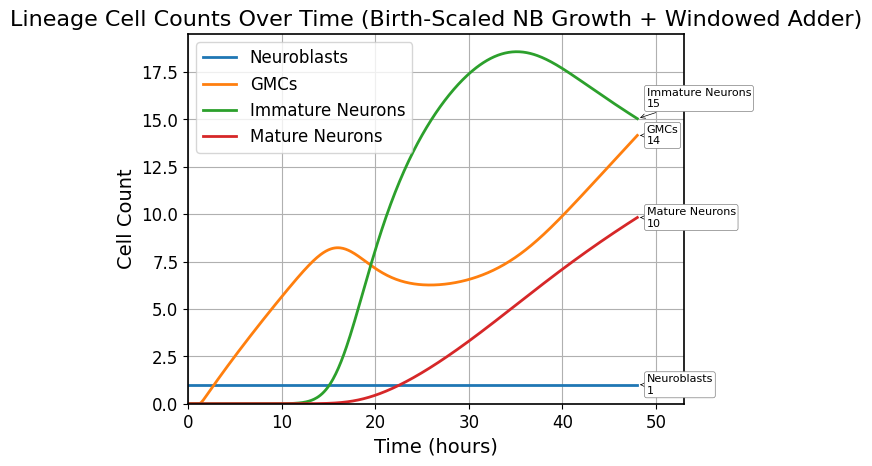

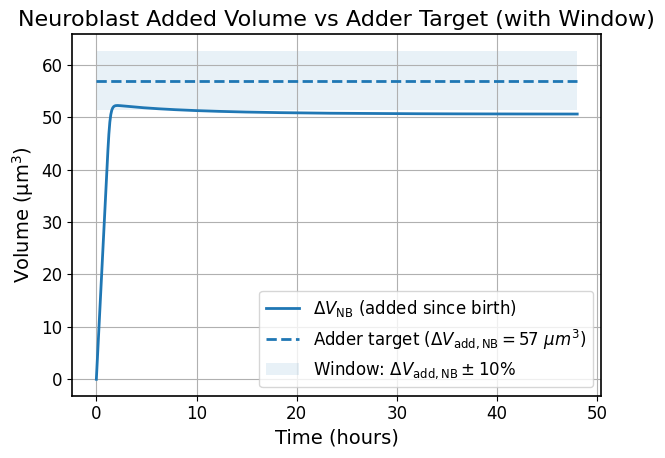

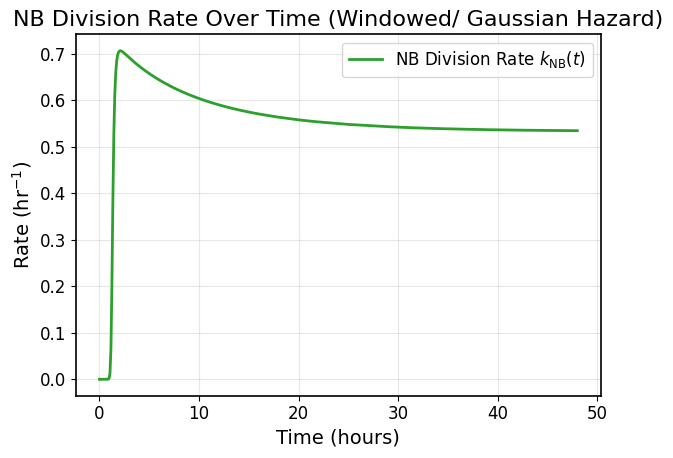

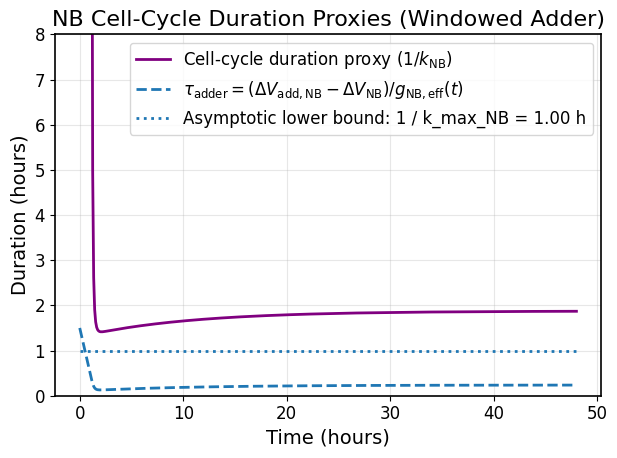

In [72]:
# --- WT params (birth-scaled NB growth + windowed/gaussian adder hazard) ---
nb_vol = 285                                # Initial neuroblast volume (µm³)

g_NB_base = nb_vol * 0.2 / 1.5              # NB base growth rate (volume/hr)
g_GMC     = (nb_vol * 1.2 * 0.2) / 9        # GMC growth rate (volume/hr)

k_max_NB  = 1.0                             # Max NB division rate (divisions/hr)
k_max_GMC = 1.0 / 8.0                       # Max GMC division rate (divisions/hr)

sym_frac  = 0.0                             # Fraction of NB divisions that are symmetric
k_Neuron  = 1.0 / 48.0                      # Immature neuron maturation rate (1/hr)

# Adder targets (center of the Gaussian hazard window)
dV_add_NB  = 0.20 * nb_vol                  # NB target added volume
dV_add_GMC = 0.24 * nb_vol                  # GMC target added volume

# Window widths (as fractions of the target); smaller = tighter window
sigma_NB  = 0.10                            # NB hazard width (10% of dV_add_NB)
sigma_GMC = 0.15                            # GMC hazard width (15% of dV_add_GMC)

# NB growth rate scaling by birth size
V_ref        = nb_vol                       # Reference NB birth volume
alpha_birth  = 1.0                          # >0 → smaller-at-birth NBs grow more slowly

# Parameter order for the windowed-hazard model:
# (g_NB_base, g_GMC, k_Neuron, sym_frac,
#  k_max_NB, k_max_GMC,
#  dV_add_NB, dV_add_GMC,
#  sigma_NB, sigma_GMC,
#  V_ref, alpha_birth)
params_win = [
    g_NB_base, g_GMC,
    k_Neuron,
    sym_frac,
    k_max_NB, k_max_GMC,
    dV_add_NB, dV_add_GMC,
    sigma_NB, sigma_GMC,
    V_ref, alpha_birth
]

# Initial conditions
# y = [N_NB, V_NB, N_GMC, V_GMC, N_Im, V_Im, N_Mat, V_Mat, S_NB, S_GMC]
# Start with one NB whose birth volume = nb_vol, so S_NB = nb_vol; initially no GMCs, so S_GMC = 0.
y0 = [1, nb_vol, 0, 0, 0, 0, 0, 0, nb_vol, 0.0]

t_span = [0, 48]
t_eval = np.linspace(*t_span, 500)

# --- Solve ---
sol_win = solve_ivp(
    neuroblast_model_adder_windowed_hazard_birth_scaled_growth_with_SGMC,
    t_span, y0, t_eval=t_eval, args=(params_win,),
    rtol=1e-6, atol=1e-9
)

# ========== Plot 1: Cell counts ==========
fig, ax = plt.subplots()
labels  = ["Neuroblasts", "GMCs", "Immature Neurons", "Mature Neurons"]
indices = [0, 2, 4, 6]
y_data  = [sol_win.y[i] for i in indices]

for y, label in zip(y_data, labels):
    ax.plot(sol_win.t, y, label=label)

ax.set_xlim(0, sol_win.t[-1] + 5)
ax.set_ylim(bottom=0)
try:
    annotate_final_values(ax, sol_win.t, y_data, labels)
except NameError:
    pass
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Cell Count")
ax.set_title("Lineage Cell Counts Over Time (Birth-Scaled NB Growth + Windowed Adder)")
ax.grid()
ax.legend()
plt.show()

# ========== Plot 2: NB added volume (ΔV) vs adder target and window ==========
Vavg_NB = np.divide(sol_win.y[1], sol_win.y[0],
                    out=np.zeros_like(sol_win.y[1]),
                    where=sol_win.y[0] > 0)
Bavg_NB = np.divide(sol_win.y[8], sol_win.y[0],
                    out=np.zeros_like(sol_win.y[8]),
                    where=sol_win.y[0] > 0)
dV_NB_series = np.maximum(0.0, Vavg_NB - Bavg_NB)

fig, ax = plt.subplots()
ax.plot(sol_win.t, dV_NB_series, label=r"$\Delta V_{\mathrm{NB}}$ (added since birth)", linewidth=2)
ax.hlines(dV_add_NB, sol_win.t[0], sol_win.t[-1], linestyles="--",
          label=rf"Adder target ($\Delta V_{{\mathrm{{add,NB}}}}={dV_add_NB:.0f}\ \mu m^3$)")

# Show the Gaussian window (± sigma * target)
low  = (1.0 - sigma_NB) * dV_add_NB
high = (1.0 + sigma_NB) * dV_add_NB
ax.fill_between([sol_win.t[0], sol_win.t[-1]], [low, low], [high, high],
                alpha=0.1, label=rf"Window: $\Delta V_{{\mathrm{{add,NB}}}}\pm {int(100*sigma_NB)}\%$")

ax.set_xlabel("Time (hours)")
ax.set_ylabel(r"Volume (µm$^3$)")
ax.set_title("Neuroblast Added Volume vs Adder Target (with Window)")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

# ========== Plot 3: NB division rate & duration proxies ==========
# Recompute series
Vavg_NB = np.divide(sol_win.y[1], sol_win.y[0],
                    out=np.zeros_like(sol_win.y[1]),
                    where=sol_win.y[0] > 0)
Bavg_NB = np.divide(sol_win.y[8], sol_win.y[0],
                    out=np.zeros_like(sol_win.y[8]),
                    where=sol_win.y[0] > 0)
dV_NB_series = np.maximum(0.0, Vavg_NB - Bavg_NB)

# NB effective growth for τ_adder proxy
g_NB_eff_series = g_NB_base * np.where(
    V_ref > 0,
    np.power(np.divide(Bavg_NB, V_ref,
                       out=np.zeros_like(Bavg_NB), where=V_ref > 0), alpha_birth),
    1.0
)

# k_NB(t) = k_max_NB * exp( -0.5 * ((ΔV_NB - dV_add_NB)/(sigma_NB * dV_add_NB))^2 )
with np.errstate(divide='ignore', invalid='ignore'):
    x = np.where(dV_add_NB > 0, (dV_NB_series - dV_add_NB) / (sigma_NB * dV_add_NB), np.inf)
    k_NB_series = k_max_NB * np.exp(-0.5 * x * x)

# Mask to avoid divide-by-zero for 1/k
eps_k = 1e-9
valid = k_NB_series > eps_k

ccd_hazard = np.full_like(k_NB_series, np.nan, dtype=float)
ccd_hazard[valid] = 1.0 / k_NB_series[valid]

# τ_adder proxy = remaining adder / current growth rate
tau_adder = np.full_like(dV_NB_series, np.nan, dtype=float)
mask_g = g_NB_eff_series > eps_k
tau_adder[mask_g] = np.maximum(0.0, dV_add_NB - dV_NB_series[mask_g]) / g_NB_eff_series[mask_g]

fig, ax = plt.subplots()
ax.plot(sol_win.t, k_NB_series, color="tab:green",
        label=r"NB Division Rate $k_{\mathrm{NB}}(t)$", linewidth=2)
ax.set_xlabel("Time (hours)")
ax.set_ylabel(r"Rate (hr$^{-1}$)")
ax.set_title("NB Division Rate Over Time (Windowed/ Gaussian Hazard)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
ax.plot(sol_win.t, ccd_hazard, color="purple",
        label=r"Cell-cycle duration proxy ($1/k_{\mathrm{NB}}$)", linewidth=2)
ax.plot(sol_win.t, tau_adder, "--",
       label=r"$\tau_{\mathrm{adder}} = (\Delta V_{\mathrm{add,NB}}-\Delta V_{\mathrm{NB}})/g_{\mathrm{NB,eff}}(t)$")
ax.hlines(1.0 / k_max_NB, sol_win.t[0], sol_win.t[-1],
          linestyles=":", label=f"Asymptotic lower bound: 1 / k_max_NB = {1.0/k_max_NB:.2f} h")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Duration (hours)")
ax.set_ylim(0, 8)
ax.set_title("NB Cell-Cycle Duration Proxies (Windowed Adder)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

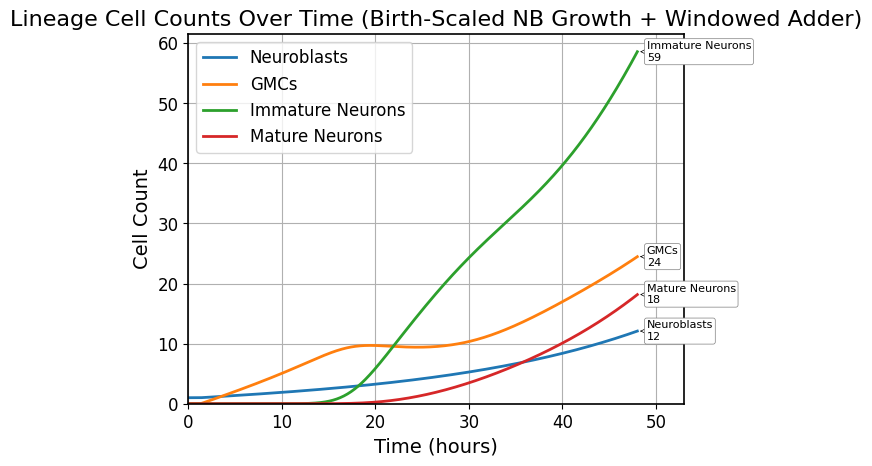

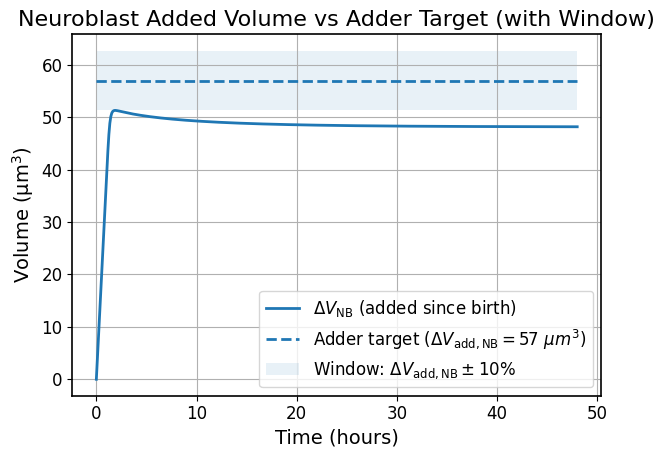

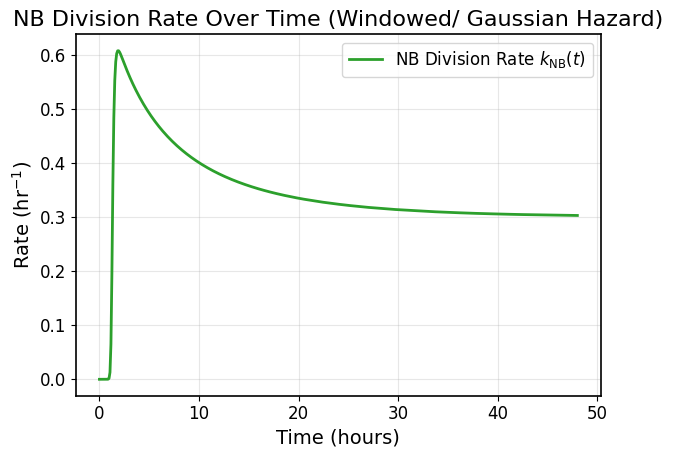

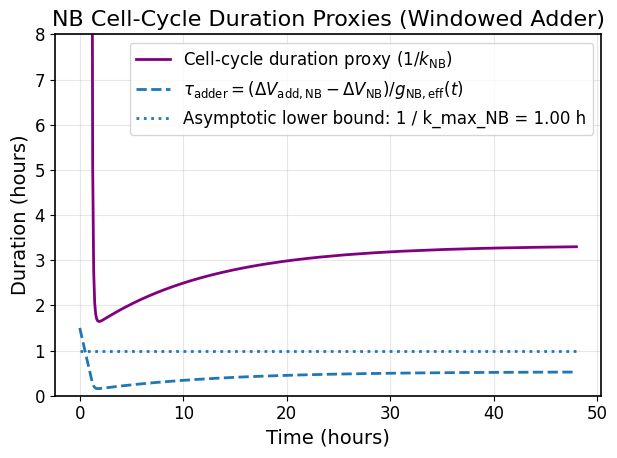

In [73]:
# --- mudmut params (birth-scaled NB growth + windowed/gaussian adder hazard) ---
nb_vol = 285                                # Initial neuroblast volume (µm³)

g_NB_base = nb_vol * 0.2 / 1.5              # NB base growth rate (volume/hr)
g_GMC     = (nb_vol * 1.2 * 0.2) / 9        # GMC growth rate (volume/hr)

k_max_NB  = 1.0                             # Max NB division rate (divisions/hr)
k_max_GMC = 1.0 / 8.0                       # Max GMC division rate (divisions/hr)

sym_frac  = 0.15                             # Fraction of NB divisions that are symmetric
k_Neuron  = 1.0 / 48.0                      # Immature neuron maturation rate (1/hr)

# Adder targets (center of the Gaussian hazard window)
dV_add_NB  = 0.20 * nb_vol                  # NB target added volume
dV_add_GMC = 0.24 * nb_vol                  # GMC target added volume

# Window widths (as fractions of the target); smaller = tighter window
sigma_NB  = 0.10                            # NB hazard width (10% of dV_add_NB)
sigma_GMC = 0.15                            # GMC hazard width (15% of dV_add_GMC)

# NB growth rate scaling by birth size
V_ref        = nb_vol                       # Reference NB birth volume
alpha_birth  = 1.0                          # >0 → smaller-at-birth NBs grow more slowly

# Parameter order for the windowed-hazard model:
# (g_NB_base, g_GMC, k_Neuron, sym_frac,
#  k_max_NB, k_max_GMC,
#  dV_add_NB, dV_add_GMC,
#  sigma_NB, sigma_GMC,
#  V_ref, alpha_birth)
params_win = [
    g_NB_base, g_GMC,
    k_Neuron,
    sym_frac,
    k_max_NB, k_max_GMC,
    dV_add_NB, dV_add_GMC,
    sigma_NB, sigma_GMC,
    V_ref, alpha_birth
]

# Initial conditions
# y = [N_NB, V_NB, N_GMC, V_GMC, N_Im, V_Im, N_Mat, V_Mat, S_NB, S_GMC]
# Start with one NB whose birth volume = nb_vol, so S_NB = nb_vol; initially no GMCs, so S_GMC = 0.
y0 = [1, nb_vol, 0, 0, 0, 0, 0, 0, nb_vol, 0.0]

t_span = [0, 48]
t_eval = np.linspace(*t_span, 500)

# --- Solve ---
sol_win = solve_ivp(
    neuroblast_model_adder_windowed_hazard_birth_scaled_growth_with_SGMC,
    t_span, y0, t_eval=t_eval, args=(params_win,),
    rtol=1e-6, atol=1e-9
)

# ========== Plot 1: Cell counts ==========
fig, ax = plt.subplots()
labels  = ["Neuroblasts", "GMCs", "Immature Neurons", "Mature Neurons"]
indices = [0, 2, 4, 6]
y_data  = [sol_win.y[i] for i in indices]

for y, label in zip(y_data, labels):
    ax.plot(sol_win.t, y, label=label)

ax.set_xlim(0, sol_win.t[-1] + 5)
ax.set_ylim(bottom=0)
try:
    annotate_final_values(ax, sol_win.t, y_data, labels)
except NameError:
    pass
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Cell Count")
ax.set_title("Lineage Cell Counts Over Time (Birth-Scaled NB Growth + Windowed Adder)")
ax.grid()
ax.legend()
plt.show()

# ========== Plot 2: NB added volume (ΔV) vs adder target and window ==========
Vavg_NB = np.divide(sol_win.y[1], sol_win.y[0],
                    out=np.zeros_like(sol_win.y[1]),
                    where=sol_win.y[0] > 0)
Bavg_NB = np.divide(sol_win.y[8], sol_win.y[0],
                    out=np.zeros_like(sol_win.y[8]),
                    where=sol_win.y[0] > 0)
dV_NB_series = np.maximum(0.0, Vavg_NB - Bavg_NB)

fig, ax = plt.subplots()
ax.plot(sol_win.t, dV_NB_series, label=r"$\Delta V_{\mathrm{NB}}$ (added since birth)", linewidth=2)
ax.hlines(dV_add_NB, sol_win.t[0], sol_win.t[-1], linestyles="--",
          label=rf"Adder target ($\Delta V_{{\mathrm{{add,NB}}}}={dV_add_NB:.0f}\ \mu m^3$)")

# Show the Gaussian window (± sigma * target)
low  = (1.0 - sigma_NB) * dV_add_NB
high = (1.0 + sigma_NB) * dV_add_NB
ax.fill_between([sol_win.t[0], sol_win.t[-1]], [low, low], [high, high],
                alpha=0.1, label=rf"Window: $\Delta V_{{\mathrm{{add,NB}}}}\pm {int(100*sigma_NB)}\%$")

ax.set_xlabel("Time (hours)")
ax.set_ylabel(r"Volume (µm$^3$)")
ax.set_title("Neuroblast Added Volume vs Adder Target (with Window)")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

# ========== Plot 3: NB division rate & duration proxies ==========
# Recompute series
Vavg_NB = np.divide(sol_win.y[1], sol_win.y[0],
                    out=np.zeros_like(sol_win.y[1]),
                    where=sol_win.y[0] > 0)
Bavg_NB = np.divide(sol_win.y[8], sol_win.y[0],
                    out=np.zeros_like(sol_win.y[8]),
                    where=sol_win.y[0] > 0)
dV_NB_series = np.maximum(0.0, Vavg_NB - Bavg_NB)

# NB effective growth for τ_adder proxy
g_NB_eff_series = g_NB_base * np.where(
    V_ref > 0,
    np.power(np.divide(Bavg_NB, V_ref,
                       out=np.zeros_like(Bavg_NB), where=V_ref > 0), alpha_birth),
    1.0
)

# k_NB(t) = k_max_NB * exp( -0.5 * ((ΔV_NB - dV_add_NB)/(sigma_NB * dV_add_NB))^2 )
with np.errstate(divide='ignore', invalid='ignore'):
    x = np.where(dV_add_NB > 0, (dV_NB_series - dV_add_NB) / (sigma_NB * dV_add_NB), np.inf)
    k_NB_series = k_max_NB * np.exp(-0.5 * x * x)

# Mask to avoid divide-by-zero for 1/k
eps_k = 1e-9
valid = k_NB_series > eps_k

ccd_hazard = np.full_like(k_NB_series, np.nan, dtype=float)
ccd_hazard[valid] = 1.0 / k_NB_series[valid]

# τ_adder proxy = remaining adder / current growth rate
tau_adder = np.full_like(dV_NB_series, np.nan, dtype=float)
mask_g = g_NB_eff_series > eps_k
tau_adder[mask_g] = np.maximum(0.0, dV_add_NB - dV_NB_series[mask_g]) / g_NB_eff_series[mask_g]

fig, ax = plt.subplots()
ax.plot(sol_win.t, k_NB_series, color="tab:green",
        label=r"NB Division Rate $k_{\mathrm{NB}}(t)$", linewidth=2)
ax.set_xlabel("Time (hours)")
ax.set_ylabel(r"Rate (hr$^{-1}$)")
ax.set_title("NB Division Rate Over Time (Windowed/ Gaussian Hazard)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
ax.plot(sol_win.t, ccd_hazard, color="purple",
        label=r"Cell-cycle duration proxy ($1/k_{\mathrm{NB}}$)", linewidth=2)
ax.plot(sol_win.t, tau_adder, "--",
       label=r"$\tau_{\mathrm{adder}} = (\Delta V_{\mathrm{add,NB}}-\Delta V_{\mathrm{NB}})/g_{\mathrm{NB,eff}}(t)$")
ax.hlines(1.0 / k_max_NB, sol_win.t[0], sol_win.t[-1],
          linestyles=":", label=f"Asymptotic lower bound: 1 / k_max_NB = {1.0/k_max_NB:.2f} h")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Duration (hours)")
ax.set_ylim(0, 8)
ax.set_title("NB Cell-Cycle Duration Proxies (Windowed Adder)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()